# Conflict Escalation Dashboard (Colab, Sectioned)

This notebook is structured to run **top to bottom** in Google Colab.

It will:

1. install packages
2. import libraries
3. pull market data
4. pull GDELT and RSS fallback data, and optionally ACLED
5. build the conflict escalation model (Heuristic + Random Forest ML)
6. create charts
7. export CSV files
8. generate a formatted PDF report

## Notes
- If GDELT rate-limits you, the notebook now falls back to **RSS-derived keyword signals** instead of synthetic placeholders.
- If ACLED credentials are not provided, the notebook will continue without ACLED.
- Missing data no longer silently dilutes the model: the score is now **availability-adjusted**.
- Run **Runtime → Run all** in Colab for the smoothest experience.


In [1]:
# SECTION 1 — Install packages
!pip -q install yfinance requests pandas numpy matplotlib plotly reportlab scipy scikit-learn feedparser
# BigQuery (optional — only needed if ENABLE_BIGQUERY = True)
!pip -q install google-cloud-bigquery db-dtypes

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 4.4 MB/s eta 0:00:00


In [2]:
# SECTION 2 — Imports
import os
import pathlib
import time
import random
import warnings
from datetime import datetime

import requests
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import plotly.graph_objects as go

from scipy.special import softmax
from sklearn.preprocessing import StandardScaler
import feedparser

warnings.filterwarnings("ignore")

from IPython.display import display, Markdown

In [ ]:
# SECTION 2a — Papermill-injectable parameters
# These defaults are used for interactive Colab runs.
# GitHub Actions (and any papermill caller) overrides them via -p flags:
#   papermill ... -p USE_DRIVE False -p OUTPUT_DIR 'outputs/' \
#                 -p ENABLE_BIGQUERY True -p GCP_PROJECT_ID 'my-project'

USE_DRIVE    = True             # set False in CI / local runs without Drive
DRIVE_FOLDER = 'IranDashboard'  # My Drive folder name
OUTPUT_DIR   = None             # None = auto-set by Drive mount cell below

# BigQuery parameters — overridden in CI via -p ENABLE_BIGQUERY True
ENABLE_BIGQUERY = True          # False → REST API + RSS fallback (no credentials)
GCP_PROJECT_ID  = 'iran-conflict-dashboard'  # override in CI via GCP_PROJECT_ID secret


In [ ]:
# SECTION 2b — Persist outputs to Google Drive
#
# All output files (CSV history, PDF reports, charts) are written to a
# folder in your Google Drive so they survive Colab runtime disconnects.
#
# First run: you will see a Google auth popup — use the same account as
# BigQuery. The folder is created automatically if it doesn't exist.
#
# To disable Drive persistence and write locally instead, set:
#   USE_DRIVE = False

# USE_DRIVE and DRIVE_FOLDER are declared in the parameters cell above.
# Papermill overrides them before this cell runs.

if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    import os
    if OUTPUT_DIR is None:
        OUTPUT_DIR = f'/content/drive/MyDrive/{DRIVE_FOLDER}/'
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    print(f'Drive mounted. Outputs will be saved to: {OUTPUT_DIR}')
else:
    import os
    if OUTPUT_DIR is None:
        OUTPUT_DIR = ''  # write to current Colab directory
    if OUTPUT_DIR:
        os.makedirs(OUTPUT_DIR, exist_ok=True)
    print(f'Drive persistence disabled. Outputs: {OUTPUT_DIR or "current directory"}')


## Section 3 — Configuration

Set the model knobs here.

`ENABLE_GDELT` is left on by default, but the query count is intentionally reduced to lower rate-limit risk.


A 60-day warm-up buffer is added to the market download so rolling level-based shocks are fully initialized before the final 90-day dashboard window is plotted.


In [3]:
# SECTION 3 — Configuration

LOOKBACK_DAYS = 90
NEWS_LOOKBACK_DAYS = 30

ENABLE_GDELT      = True
ENABLE_ACLED      = False  # set True only if you provide credentials below

# ── BigQuery GDELT (optional, higher reliability) ────────────────────────
# Set ENABLE_BIGQUERY = True and supply your GCP project ID to query GDELT
# via BigQuery instead of the rate-limited public REST API.
# In Colab: auth popup appears automatically on first run.
# Local:    set env var GOOGLE_APPLICATION_CREDENTIALS to your service-account JSON path.
# ENABLE_BIGQUERY and GCP_PROJECT_ID are set in the parameters cell (Section 2a).
# Override them there for interactive runs, or via papermill -p flags in CI.
# ⚠️  GCP_PROJECT_ID must be YOUR OWN project ID — see README → GDELT → Option A.
   # set True only if you provide credentials below
ENABLE_OSINT = True    # Download OSINT attack-wave DB from GitHub (no credentials needed)
OSINT_DB_URL = "https://github.com/danielrosehill/Iran-Israel-War-2026-OSINT-Data/raw/main/data/iran_israel_war.db"

GDELT_QUERY_SET = {
    "iran_conflict_volume":    '"Iran" AND ("Israel" OR "United States" OR "Pentagon") AND (missile OR strike OR drone OR attack OR bomb)',
    "ceasefire_volume":        '("Iran" OR "Israel" OR "United States") AND (ceasefire OR negotiation OR mediation OR talks OR diplomacy)',
    "iran_conflict_tone":      '"Iran" AND ("Israel" OR "United States") AND (missile OR strike OR drone)',
    "hormuz_tone":             '"Strait of Hormuz" AND (shipping OR tanker OR blockade OR disruption)',
    # ── New signals: persistent escalation drivers ───────────────────────
    "troop_deployment_volume": '"Iran" AND ("United States" OR "US forces" OR "Pentagon") AND (troops OR forces OR deployment OR military)',
    "nuclear_volume":          '"Iran" AND (nuclear OR uranium OR enrichment OR centrifuge OR "nuclear deal")',
    "sanctions_volume":        '"Iran" AND (sanctions OR embargo OR "economic pressure" OR "financial pressure")',
    # ── US military engagement (tripartite conflict: Iran-Israel-US) ─────────
    "us_strike_volume":        '"United States" AND ("Iran" OR "IRGC" OR "Houthi" OR "Iran-backed") AND (strike OR attack OR bomb OR missile OR retaliation)',
    "us_casualties_volume":    '("American" OR "US troops" OR "US forces" OR "US military") AND (killed OR casualties OR wounded) AND ("Middle East" OR Iran OR Iraq OR Syria OR Yemen OR "Red Sea")',
    # ── Lebanon front + Israeli operations + US force posture ─────────────
    "hezbollah_volume":        '"Hezbollah" AND ("Israel" OR "Lebanon" OR "Iran") AND (attack OR strike OR rocket OR missile OR operation OR fire)',
    "israel_strikes_volume":   '("Israel" OR "IDF" OR "Israeli military") AND ("Iran" OR "Syria" OR "Lebanon" OR "Gaza") AND (airstrike OR strike OR attack OR bomb OR operation)',
    "us_centcom_volume":       '("CENTCOM" OR "carrier strike group" OR "B-2" OR "Fifth Fleet") AND ("Middle East" OR Iran OR "Persian Gulf" OR "Red Sea") AND (deploy OR strike OR operation OR mission)',
    # ── War expansion watchlist queries ──────────────────────────────────────
    "expansion_volume":        '("Saudi Arabia" OR "Jordan" OR "Turkey" OR "Iraq") AND ("Iran" OR "Israel" OR "United States") AND (military OR strike OR attack OR conflict OR war OR troops)',
    "saudi_conflict_volume":   '"Saudi Arabia" AND ("Iran" OR "Houthi" OR "Yemen") AND (military OR attack OR strike OR missile OR war OR conflict)',
    "russia_iran_volume":      '"Russia" AND "Iran" AND (military OR weapons OR cooperation OR support OR alliance OR deal)',
    # ── Bab al-Mandeb / Red Sea chokepoint queries ───────────────────────────
    "bab_mandeb_volume":        '("Bab al-Mandeb" OR "Red Sea") AND ("Houthi" OR "Yemen" OR ship OR vessel OR tanker OR attack OR drone OR missile)',
    "red_sea_attack_volume":    '("Red Sea" OR "Gulf of Aden") AND ("Houthi" OR "Ansar Allah") AND (attack OR strike OR missile OR drone OR vessel OR cargo)',
}

ACLED_EMAIL = os.getenv("ACLED_EMAIL", "")
ACLED_PASSWORD = os.getenv("ACLED_PASSWORD", "")

TODAY = pd.Timestamp.utcnow().tz_localize(None).normalize()
WARMUP_DAYS = 120   # increased from 60 to support 120-day level signals
START_DATE = TODAY - pd.Timedelta(days=LOOKBACK_DAYS + WARMUP_DAYS)

TICKERS = [
    "BZ=F",   # Brent crude
    "CL=F",   # WTI crude
    "NG=F",   # Nat gas
    "^VIX",   # VIX
    "UUP",    # USD proxy
    "XLE",    # Energy equities
    "XLI",    # Industrials
    "ITA",    # Defense / aerospace proxy
    "GLD",    # Gold
    "TLT",    # Long duration Treasuries
    "HYG",    # High yield credit
    "SPY",    # Broad equity benchmark
    "BTC-USD",# Bitcoin proxy
    "ETH-USD",# Ethereum proxy
    # ── Physical Hormuz proxies (P3) ─────
    "FRO",    # Frontline — VLCC spot-rate sensitive
    "STNG",   # Scorpio Tankers — product tanker
    "DHT",    # DHT Holdings — VLCC
    # ── Direct conflict market signals ────────────────────────────────────
    "ILS=X",  # Israeli Shekel/USD — best single-market escalation signal
    "^OVX",   # CBOE Crude Oil Volatility — options-market fear gauge
    # ── Defense primes (more specific than ITA basket) ───────────────────
    "LMT",    # Lockheed Martin
    "RTX",    # Raytheon Technologies
    "NOC",    # Northrop Grumman
    # ── Bab al-Mandeb / Red Sea chokepoint proxies ────────────────────────
    "ZIM",    # ZIM Integrated Shipping — container; falls when Red Sea avoided
    "SBLK",   # Star Bulk Carriers — dry bulk; Cape rerouting cost proxy
]

TANKER_TICKERS = ["FRO", "STNG", "DHT"]
DEFENSE_PRIME_TICKERS = ["LMT", "RTX", "NOC"]

# Wikipedia articles to monitor for edit velocity (early-warning, no credentials needed)
WIKI_CONFLICT_ARTICLES = [
    "2024_Iran%E2%80%93Israel_conflict",
    "Iran%E2%80%93Israel_proxy_conflict",
    "Hezbollah",
    "Islamic_Revolutionary_Guard_Corps",
]

# ── War expansion actor tiers ────────────────────────────────────────────
# Used by GDELT Events query to build dynamic actor sets.
# Promote countries from watchlist → active as conflict expands.
CONFLICT_ACTOR_TIERS = {
    "core":        ["IRN", "ISR", "USA"],           # Direct belligerents
    "active":      ["LBN", "YEM"],                  # Active proxy fronts (always queried)
    "watchlist":   ["SAU", "JOR", "TUR", "IRQ"],    # Regional escalation watchlist
    "great_power": ["RUS", "CHN"],                  # Great-power involvement tier
}

# ── Output paths — all prefixed with OUTPUT_DIR (set in Section 2b) ──────
# OUTPUT_DIR is "" if Drive is disabled, so paths fall back to local Colab disk.
OUTPUT_CSV_FULL       = OUTPUT_DIR + "conflict_escalation_dashboard_output.csv"
OUTPUT_CSV_LATEST     = OUTPUT_DIR + "conflict_dashboard_latest.csv"
OUTPUT_PDF            = OUTPUT_DIR + "conflict_dashboard_report.pdf"
OUTPUT_IMG_ESC        = OUTPUT_DIR + "conflict_escalation_chart.png"
OUTPUT_IMG_DUR        = OUTPUT_DIR + "conflict_duration_chart.png"
OUTPUT_IMG_CONTRIB    = OUTPUT_DIR + "signal_contributions_chart.png"
OUTPUT_INDEX_HISTORY  = OUTPUT_DIR + "escalation_index_history.csv"
OUTPUT_IMG_INDEX      = OUTPUT_DIR + "escalation_index_chart.png"
OUTPUT_IMG_LEADLAG    = OUTPUT_DIR + "osint_lead_lag_chart.png"
OUTPUT_IMG_BACKTEST   = OUTPUT_DIR + "backtest_validation_chart.png"
VALIDATION_START = pd.Timestamp("2024-01-01")  # pre-TP1 baseline; market data pulled from here
N_BOOTSTRAP = 500                               # ICEI confidence-interval samples
ENABLE_WEIGHT_OPTIMIZATION = True               # derive market weights via logistic regression

## Section 4 — Helper functions

In [4]:
# SECTION 4 — Helper functions

def robust_get(url, params=None, headers=None, timeout=30, max_retries=6):
    last_err = RuntimeError("Request failed without a captured exception.")
    for attempt in range(max_retries):
        try:
            r = requests.get(url, params=params, headers=headers, timeout=timeout)
            if r.status_code == 429:
                wait = min((2 ** attempt) + random.uniform(0.5, 1.5), 20)
                print(f"Rate-limited (429). Sleeping {wait:.1f}s...")
                time.sleep(wait)
                continue
            r.raise_for_status()
            return r
        except requests.exceptions.RequestException as e:
            last_err = e
            wait = min((2 ** attempt) + random.uniform(0.5, 1.5), 20)
            time.sleep(wait)
    raise last_err

def safe_json(response):
    try:
        return response.json()
    except Exception as e:
        raise ValueError(f"Failed to decode JSON: {e}")

def safe_pct_change(series, periods=1):
    s = series.copy()
    return s.pct_change(periods=periods).replace([np.inf, -np.inf], np.nan)

def rolling_zscore(series, window=20):
    mean = series.rolling(window).mean()
    std = series.rolling(window).std()
    z = (series - mean) / std
    return z.replace([np.inf, -np.inf], np.nan)

def clip_series(series, low=-3, high=3):
    return series.clip(lower=low, upper=high)

def normalize_to_minus1_plus1(z, clip=3):
    z = np.clip(z, -clip, clip)
    return z / clip

def fmt_num(x, nd=3):
    try:
        return f"{float(x):.{nd}f}"
    except Exception:
        return str(x)

def fmt_pct(x):
    try:
        return f"{float(x):.1%}"
    except Exception:
        return str(x)

def ensure_naive_datetime_index(df_or_series):
    """Force DatetimeIndex to tz-naive so joins/merges do not fail in Colab."""
    if isinstance(df_or_series, (pd.DataFrame, pd.Series)):
        idx = df_or_series.index
        if isinstance(idx, pd.DatetimeIndex):
            if idx.tz is not None:
                df_or_series = df_or_series.copy()
                try:
                    df_or_series.index = idx.tz_convert(None)
                except Exception:
                    df_or_series.index = pd.to_datetime(idx, utc=True).tz_convert(None)
    return df_or_series


## Section 5 — Data pull functions

In [5]:

# SECTION 5 — Data pull functions

GDELT_BASE = "https://api.gdeltproject.org/api/v2/doc/doc"

RSS_FEED_URLS = [
    "https://news.google.com/rss?hl=en-US&gl=US&ceid=US:en",
    "https://news.google.com/rss/search?q=Iran+Israel&hl=en-US&gl=US&ceid=US:en",
    "https://news.google.com/rss/search?q=Strait+of+Hormuz+shipping&hl=en-US&gl=US&ceid=US:en",
    "https://news.google.com/rss/search?q=Hezbollah+Houthis+Iraqi+militias&hl=en-US&gl=US&ceid=US:en",
]

RSS_SIGNAL_QUERIES = {
    "iran_conflict_volume": {
        "must": ["iran"],
        "any": ["israel", "united states", "u.s.", "us"],
        "context": ["missile", "strike", "drone", "attack"],
    },
    "ceasefire_volume": {
        "must": ["iran", "israel"],
        "context": ["ceasefire", "negotiation", "mediation", "talks"],
    },
    "hormuz_disruption_volume": {
        "must": ["strait of hormuz"],
        "context": ["shipping", "tanker", "blockade", "disruption", "insurance"],
    },
    "proxy_attack_volume": {
        "any": ["hezbollah", "houthis", "iraqi militias"],
        "context": ["attack", "strike", "missile", "drone"],
    },
    "iran_instability_volume": {
        "must": ["iran"],
        "context": ["protest", "unrest", "succession", "leadership crisis", "internal dissent", "leadership"],
    },
}

NEGATIVE_TERMS = [
    "attack", "strike", "missile", "drone", "killed", "dead", "escalation",
    "explosion", "blockade", "crisis", "threat", "retaliation", "sanction",
    "disruption", "war", "conflict", "military", "airstrike", "casualties"
]

def extract_close(df, ticker):
    if len(df.columns) == 0:
        return pd.Series(dtype=float)
    try:
        if ticker not in df.columns.get_level_values(0):
            return pd.Series(dtype=float)
        x = df[ticker]["Close"].copy()
        x.name = ticker
        return x
    except Exception:
        return pd.Series(dtype=float)

def pull_market_data(start=None):
    start = start or START_DATE
    market = yf.download(
        tickers=TICKERS,
        start=start.strftime("%Y-%m-%d"),
        end=(TODAY + pd.Timedelta(days=1)).strftime("%Y-%m-%d"),
        auto_adjust=True,
        progress=False,
        group_by="ticker",
    )
    market_close = pd.DataFrame({t: extract_close(market, t) for t in TICKERS}).sort_index()
    market_close = market_close.ffill()
    market_close = ensure_naive_datetime_index(market_close)
    return market_close

def gdelt_timeline(query, mode="TimelineVol", timespan="30d"):
    params = {
        "query": query,
        "mode": mode,
        "format": "json",
        "timespan": timespan,
    }
    r = robust_get(GDELT_BASE, params=params, timeout=45)
    data = safe_json(r)
    if not isinstance(data, dict):
        return pd.Series(dtype=float)

    timeline_candidates = []
    for key in ["timeline", "timelineVol", "timelineTone", "articles"]:
        if key in data and isinstance(data[key], list):
            timeline_candidates = data[key]
            break

    if not timeline_candidates:
        return pd.Series(dtype=float)

    rows = []
    for item in timeline_candidates:
        if not isinstance(item, dict):
            continue
        dt = item.get("date") or item.get("datetime")
        if dt is None:
            continue
        val = (
            item.get("value") if item.get("value") is not None
            else item.get("norm") if item.get("norm") is not None
            else item.get("tone") if item.get("tone") is not None
            else np.nan
        )
        try:
            dt = pd.to_datetime(dt, utc=True).tz_convert(None)
        except Exception:
            continue
        rows.append((dt, val))
    if not rows:
        return pd.Series(dtype=float)

    out = pd.DataFrame(rows, columns=["date", "value"]).dropna(subset=["date"])
    out = out.groupby("date", as_index=True)["value"].mean().sort_index()
    return out

def _match_rule(text, rule):
    txt = text.lower()
    must = rule.get("must", [])
    any_terms = rule.get("any", [])
    context = rule.get("context", [])
    if must and not all(term in txt for term in must):
        return False
    if any_terms and not any(term in txt for term in any_terms):
        return False
    if context and not any(term in txt for term in context):
        return False
    return True

def _negativity_score(text):
    txt = text.lower()
    return -sum(txt.count(term) for term in NEGATIVE_TERMS)

def pull_rss_fallback_data():
    rows = []
    feeds_ok = 0
    start_cutoff = TODAY - pd.Timedelta(days=NEWS_LOOKBACK_DAYS)
    for url in RSS_FEED_URLS:
        try:
            feed = feedparser.parse(url)
            if getattr(feed, "bozo", 0):
                continue
            feeds_ok += 1
            for entry in feed.entries:
                txt = " ".join([
                    getattr(entry, "title", "") or "",
                    getattr(entry, "summary", "") or "",
                ]).strip()
                if not txt:
                    continue
                published = getattr(entry, "published_parsed", None) or getattr(entry, "updated_parsed", None)
                if published is not None:
                    dt = pd.Timestamp(*published[:6]).normalize()
                else:
                    dt = TODAY.normalize()
                dt = pd.to_datetime(dt).tz_localize(None)
                if dt < start_cutoff:
                    continue

                row = {"date": dt}
                for key, rule in RSS_SIGNAL_QUERIES.items():
                    row[key] = 1 if _match_rule(txt, rule) else 0

                # Tone proxies: more negative language => lower value
                if _match_rule(txt, RSS_SIGNAL_QUERIES["iran_conflict_volume"]):
                    row["iran_conflict_tone"] = _negativity_score(txt)
                if _match_rule(txt, RSS_SIGNAL_QUERIES["hormuz_disruption_volume"]):
                    row["hormuz_tone"] = _negativity_score(txt)

                rows.append(row)
        except Exception:
            continue

    if not rows:
        print("RSS fallback did not return usable data.")
        return pd.DataFrame()

    rss_df = pd.DataFrame(rows)
    agg = {}
    for col in [
        "iran_conflict_volume", "ceasefire_volume", "hormuz_disruption_volume",
        "proxy_attack_volume", "iran_instability_volume"
    ]:
        if col in rss_df.columns:
            agg[col] = "sum"
    for col in ["iran_conflict_tone", "hormuz_tone"]:
        if col in rss_df.columns:
            agg[col] = "mean"

    rss_df = rss_df.groupby("date", as_index=True).agg(agg).sort_index()
    rss_df = ensure_naive_datetime_index(rss_df)
    print(f"RSS fallback populated using {feeds_ok} feed(s).")
    return rss_df


def pull_gdelt_bigquery(project_id, lookback_days=30):
    """Query GDELT via BigQuery GKG table — no rate limits, full fidelity.

    Uses the same four signal slots as the REST API (iran_conflict_volume,
    ceasefire_volume, iran_conflict_tone, hormuz_tone) so the rest of the
    pipeline is unchanged.

    Auth (automatic in Colab):
      - Colab  : triggers google.colab.auth sign-in popup on first call.
      - Local  : set GOOGLE_APPLICATION_CREDENTIALS env var to your
                 service-account JSON path (BigQuery Job User role is enough).

    The DATE field (INT64, YYYYMMDDHHMMSS format) is used to filter to
    the lookback window. Note: gdelt-bq.gdeltv2.gkg is not a native
    partitioned table so _PARTITIONDATE is not available.

    Locations field format: type#fullname#countrycode#adm1code#lat#lon#featureid;...
      Iran country code : IR
      Israel country code: IS
      United States code : US

    GDELT Themes are always uppercase (e.g. MILITARY, TERROR, CRISISLEX_T03).
    """
    try:
        from google.cloud import bigquery
    except ImportError:
        print("BigQuery: google-cloud-bigquery not installed — falling back to REST API.")
        return pd.DataFrame()

    # ── Auth ────────────────────────────────────────────────────────────────
    # In Colab, authenticate_user() sets an OAuth2 session but does NOT
    # automatically wire credentials into google.auth.default().
    # We must explicitly fetch the credentials and pass them to the client.
    _creds = None
    try:
        from google.colab import auth as _colab_auth
        _colab_auth.authenticate_user()
        import google.auth
        _creds, _ = google.auth.default()
    except ImportError:
        pass  # Not in Colab — fall through to ADC / GOOGLE_APPLICATION_CREDENTIALS
    except Exception as e:
        print(f"BigQuery: Colab auth error ({e}) — trying ADC.")

    try:
        client = (
            bigquery.Client(project=project_id, credentials=_creds)
            if _creds is not None
            else bigquery.Client(project=project_id)
        )
    except Exception as e:
        print(f"BigQuery: authentication failed ({e}) — falling back to REST API.")
        return pd.DataFrame()

    # ── Date bounds ─────────────────────────────────────────────────────────
    # DATE INT64 filter limits results to the lookback window.
    lookback_start = TODAY - pd.Timedelta(days=lookback_days)
    date_int_start  = int(lookback_start.strftime('%Y%m%d')) * 1000000  # e.g. 20250225000000

    queries = {
        # ── Volume: Iran + (Israel OR US) articles with conflict themes ──────
        "iran_conflict_volume": f"""
            SELECT
                PARSE_DATE('%Y%m%d', SUBSTR(CAST(DATE AS STRING), 1, 8)) AS day,
                COUNT(*) AS value
            FROM `gdelt-bq.gdeltv2.gkg`
            WHERE DATE >= {date_int_start}
              AND Locations LIKE '%#IR#%'
              AND (Locations LIKE '%#IS#%' OR Locations LIKE '%#US#%')
              AND (   Themes LIKE '%MILITARY%'
                   OR Themes LIKE '%TERROR%'
                   OR Themes LIKE '%CRISISLEX%'
                   OR Themes LIKE '%KILLING%'
                   OR Themes LIKE '%WMD%')
            GROUP BY day
            ORDER BY day
        """,

        # ── Volume: Iran/Israel articles with diplomacy/ceasefire themes ─────
        "ceasefire_volume": f"""
            SELECT
                PARSE_DATE('%Y%m%d', SUBSTR(CAST(DATE AS STRING), 1, 8)) AS day,
                COUNT(*) AS value
            FROM `gdelt-bq.gdeltv2.gkg`
            WHERE DATE >= {date_int_start}
              AND (Locations LIKE '%#IR#%' OR Locations LIKE '%#IS#%')
              AND (   Themes LIKE '%NEGOTIATION%'
                   OR Themes LIKE '%CEASEFIRE%'
                   OR Themes LIKE '%PEACETALK%'
                   OR Themes LIKE '%DIPLOMACY%'
                   OR Themes LIKE '%MEDIATION%'
                   OR Themes LIKE '%PEACE_PROPOSAL%')
            GROUP BY day
            ORDER BY day
        """,

        # ── Tone: average sentiment of Iran/Israel conflict articles ─────────
        # GDELT V2Tone field: "overall,pos,neg,polarity,arf,self_ref,wordcount"
        # Negative overall tone = more hostile/conflict language.
        "iran_conflict_tone": f"""
            SELECT
                PARSE_DATE('%Y%m%d', SUBSTR(CAST(DATE AS STRING), 1, 8)) AS day,
                AVG(SAFE_CAST(SPLIT(V2Tone, ',')[SAFE_OFFSET(0)] AS FLOAT64)) AS value
            FROM `gdelt-bq.gdeltv2.gkg`
            WHERE DATE >= {date_int_start}
              AND Locations LIKE '%#IR#%'
              AND (Locations LIKE '%#IS#%' OR Locations LIKE '%#US#%')
              AND (   Themes LIKE '%MILITARY%'
                   OR Themes LIKE '%TERROR%'
                   OR Themes LIKE '%CRISISLEX%')
              AND V2Tone IS NOT NULL
              AND V2Tone != ''
            GROUP BY day
            ORDER BY day
        """,

        # ── Tone: sentiment of articles covering Hormuz / Iran maritime ──────
        "hormuz_tone": f"""
            SELECT
                PARSE_DATE('%Y%m%d', SUBSTR(CAST(DATE AS STRING), 1, 8)) AS day,
                AVG(SAFE_CAST(SPLIT(V2Tone, ',')[SAFE_OFFSET(0)] AS FLOAT64)) AS value
            FROM `gdelt-bq.gdeltv2.gkg`
            WHERE DATE >= {date_int_start}
              AND Locations LIKE '%#IR#%'
              AND (   Themes LIKE '%MARITIME%'
                   OR Themes LIKE '%PETROLEUM%'
                   OR Themes LIKE '%NAVAL%'
                   OR Themes LIKE '%BLOCKADE%'
                   OR Themes LIKE '%ECON_OILPRICES%'
                   OR Themes LIKE '%SHIPPING%')
              AND V2Tone IS NOT NULL
              AND V2Tone != ''
            GROUP BY day
            ORDER BY day
        """,

        # ── New: US/allied troop deployment to Middle East ───────────────────
        # US (US) + regional countries (IR=Iran, IS=Israel, SA=Saudi, IZ=Iraq, LE=Lebanon)
        "troop_deployment_volume": f"""
            SELECT
                PARSE_DATE('%Y%m%d', SUBSTR(CAST(DATE AS STRING), 1, 8)) AS day,
                COUNT(*) AS value
            FROM `gdelt-bq.gdeltv2.gkg`
            WHERE DATE >= {date_int_start}
              AND Locations LIKE '%#US#%'
              AND (   Locations LIKE '%#IR#%'
                   OR Locations LIKE '%#IS#%'
                   OR Locations LIKE '%#SA#%'
                   OR Locations LIKE '%#IZ#%'
                   OR Locations LIKE '%#LE#%')
              AND Themes LIKE '%MILITARY%'
            GROUP BY day
            ORDER BY day
        """,

        # ── New: Iran nuclear programme coverage ─────────────────────────────
        "nuclear_volume": f"""
            SELECT
                PARSE_DATE('%Y%m%d', SUBSTR(CAST(DATE AS STRING), 1, 8)) AS day,
                COUNT(*) AS value
            FROM `gdelt-bq.gdeltv2.gkg`
            WHERE DATE >= {date_int_start}
              AND Locations LIKE '%#IR#%'
              AND (Themes LIKE '%WMD%' OR Themes LIKE '%NUCLEAR%')
            GROUP BY day
            ORDER BY day
        """,

        # ── New: sanctions and economic pressure on Iran ─────────────────────
        "sanctions_volume": f"""
            SELECT
                PARSE_DATE('%Y%m%d', SUBSTR(CAST(DATE AS STRING), 1, 8)) AS day,
                COUNT(*) AS value
            FROM `gdelt-bq.gdeltv2.gkg`
            WHERE DATE >= {date_int_start}
              AND Locations LIKE '%#IR#%'
              AND (   Themes LIKE '%SANCTION%'
                   OR Themes LIKE '%EMBARGO%'
                   OR Themes LIKE '%ECON_COST%'
                   OR Themes LIKE '%ECON_TRADE%')
            GROUP BY day
            ORDER BY day
        """,

        # ── US military strikes on Iran / IRGC / Iran-backed proxies ─────────
        "us_strike_volume": f"""
            SELECT
                PARSE_DATE('%Y%m%d', SUBSTR(CAST(DATE AS STRING), 1, 8)) AS day,
                COUNT(*) AS value
            FROM `gdelt-bq.gdeltv2.gkg`
            WHERE DATE >= {date_int_start}
              AND Locations LIKE '%#US#%'
              AND (Locations LIKE '%#IR#%' OR Locations LIKE '%#YE#%' OR Locations LIKE '%#IZ#%')
              AND (   Themes LIKE '%MILITARY%'
                   OR Themes LIKE '%TERROR%'
                   OR Themes LIKE '%CRISISLEX%')
            GROUP BY day
            ORDER BY day
        """,

        # ── American military casualties in the region ────────────────────────
        "us_casualties_volume": f"""
            SELECT
                PARSE_DATE('%Y%m%d', SUBSTR(CAST(DATE AS STRING), 1, 8)) AS day,
                COUNT(*) AS value
            FROM `gdelt-bq.gdeltv2.gkg`
            WHERE DATE >= {date_int_start}
              AND Locations LIKE '%#US#%'
              AND (   Locations LIKE '%#IR#%'
                   OR Locations LIKE '%#IZ#%'
                   OR Locations LIKE '%#SY#%'
                   OR Locations LIKE '%#YE#%')
              AND (Themes LIKE '%KILLING%' OR Themes LIKE '%CASUALTY%' OR Themes LIKE '%CRISISLEX_T03%')
            GROUP BY day
            ORDER BY day
        """,

        # ── Hezbollah operations (Lebanon front) ──────────────────────────────
        "hezbollah_volume": f"""
            SELECT
                PARSE_DATE('%Y%m%d', SUBSTR(CAST(DATE AS STRING), 1, 8)) AS day,
                COUNT(*) AS value
            FROM `gdelt-bq.gdeltv2.gkg`
            WHERE DATE >= {date_int_start}
              AND Locations LIKE '%#LE#%'
              AND (Locations LIKE '%#IS#%' OR Locations LIKE '%#IR#%')
              AND (   Themes LIKE '%MILITARY%'
                   OR Themes LIKE '%TERROR%'
                   OR Themes LIKE '%CRISISLEX%')
            GROUP BY day
            ORDER BY day
        """,

        # ── Israeli airstrikes on Iran / Syria / Lebanon ──────────────────────
        "israel_strikes_volume": f"""
            SELECT
                PARSE_DATE('%Y%m%d', SUBSTR(CAST(DATE AS STRING), 1, 8)) AS day,
                COUNT(*) AS value
            FROM `gdelt-bq.gdeltv2.gkg`
            WHERE DATE >= {date_int_start}
              AND Locations LIKE '%#IS#%'
              AND (   Locations LIKE '%#IR#%'
                   OR Locations LIKE '%#SY#%'
                   OR Locations LIKE '%#LE#%')
              AND (   Themes LIKE '%MILITARY%'
                   OR Themes LIKE '%CRISISLEX%'
                   OR Themes LIKE '%AIRSTRIKE%')
            GROUP BY day
            ORDER BY day
        """,

        # ── US CENTCOM / carrier group / force posture ────────────────────────
        "us_centcom_volume": f"""
            SELECT
                PARSE_DATE('%Y%m%d', SUBSTR(CAST(DATE AS STRING), 1, 8)) AS day,
                COUNT(*) AS value
            FROM `gdelt-bq.gdeltv2.gkg`
            WHERE DATE >= {date_int_start}
              AND Locations LIKE '%#US#%'
              AND (   Locations LIKE '%#IR#%'
                   OR Locations LIKE '%#SA#%'
                   OR Locations LIKE '%#IZ#%'
                   OR Locations LIKE '%#BH#%')
              AND Themes LIKE '%MILITARY%'
            GROUP BY day
            ORDER BY day
        """,
            # ── War expansion watchlist queries ──────────────────────────
            "expansion_volume": f"""
                SELECT
                    PARSE_DATE('%Y%m%d', SUBSTR(CAST(DATE AS STRING), 1, 8)) AS day,
                    COUNT(*) AS value
                FROM `gdelt-bq.gdeltv2.gkg`
                WHERE DATE >= {date_int_start}
                  AND (   Locations LIKE '%#SA#%'
                       OR Locations LIKE '%#JO#%'
                       OR Locations LIKE '%#TR#%'
                       OR Locations LIKE '%#IZ#%')
                  AND (   Locations LIKE '%#IR#%'
                       OR Locations LIKE '%#IS#%'
                       OR Locations LIKE '%#US#%')
                  AND Themes LIKE '%MILITARY%'
                GROUP BY day ORDER BY day
            """,
            "saudi_conflict_volume": f"""
                SELECT
                    PARSE_DATE('%Y%m%d', SUBSTR(CAST(DATE AS STRING), 1, 8)) AS day,
                    COUNT(*) AS value
                FROM `gdelt-bq.gdeltv2.gkg`
                WHERE DATE >= {date_int_start}
                  AND Locations LIKE '%#SA#%'
                  AND (   Locations LIKE '%#IR#%'
                       OR Themes LIKE '%TERROR%')
                  AND Themes LIKE '%MILITARY%'
                GROUP BY day ORDER BY day
            """,
            "russia_iran_volume": f"""
                SELECT
                    PARSE_DATE('%Y%m%d', SUBSTR(CAST(DATE AS STRING), 1, 8)) AS day,
                    COUNT(*) AS value
                FROM `gdelt-bq.gdeltv2.gkg`
                WHERE DATE >= {date_int_start}
                  AND Locations LIKE '%#RS#%'
                  AND Locations LIKE '%#IR#%'
                  AND (Themes LIKE '%MILITARY%' OR Themes LIKE '%WEAPONS%')
                GROUP BY day ORDER BY day
            """,
        }

    results = {}
    all_ok = True
    for name, sql in queries.items():
        try:
            print(f"  BigQuery GDELT [{name}]...")
            df_bq = client.query(sql).to_dataframe()
            if df_bq.empty:
                print(f"  BigQuery: no rows returned for {name}.")
                results[name] = pd.Series(dtype=float)
            else:
                s = df_bq.set_index(pd.to_datetime(df_bq["day"]))["value"].sort_index()
                s.index = s.index.tz_localize(None)
                s.index.name = "date"
                results[name] = s
        except Exception as e:
            print(f"  BigQuery GDELT failed for {name}: {e}")
            results[name] = pd.Series(dtype=float)
            all_ok = False

    non_empty = {k: v for k, v in results.items() if not v.empty}
    if not non_empty:
        print("BigQuery: all queries returned empty — falling back to REST API.")
        return pd.DataFrame()

    df_out = pd.concat(non_empty, axis=1).sort_index()
    df_out = ensure_naive_datetime_index(df_out)
    n_signals = len(non_empty)
    n_total = len(queries)
    print(f"BigQuery GDELT: {n_signals}/{n_total} signals populated {'✓' if all_ok else '(partial)'}.")
    return df_out


def pull_gdelt_data():
    """Pull GDELT news signals.

    Priority order:
      1. BigQuery (if ENABLE_BIGQUERY=True) — reliable, no rate limits
      2. GDELT v2 REST API                  — free but rate-limited
      3. RSS keyword fallback               — always attempted; merged or used alone
    """
    gdelt_df = pd.DataFrame()

    # ── 1. BigQuery path ─────────────────────────────────────────────────────
    if ENABLE_BIGQUERY and GCP_PROJECT_ID:
        print("Attempting GDELT via BigQuery...")
        gdelt_df = pull_gdelt_bigquery(GCP_PROJECT_ID, lookback_days=NEWS_LOOKBACK_DAYS)

    # ── 2. REST API fallback (if BigQuery disabled or failed) ────────────────
    if gdelt_df.empty and ENABLE_GDELT:
        print("Falling back to GDELT REST API...")
        gdelt_data = {}
        for i, (name, q) in enumerate(GDELT_QUERY_SET.items(), start=1):
            mode = "TimelineTone" if "tone" in name else "TimelineVol"
            try:
                print(f"Pulling GDELT {i}/{len(GDELT_QUERY_SET)}: {name}")
                gdelt_data[name] = gdelt_timeline(q, mode=mode, timespan=f"{NEWS_LOOKBACK_DAYS}d")
            except Exception as e:
                print(f"Warning: failed GDELT pull for {name}: {e}")
                gdelt_data[name] = pd.Series(dtype=float)
            time.sleep(4.0)

        non_empty = {k: v for k, v in gdelt_data.items() if isinstance(v, pd.Series) and not v.empty}
        gdelt_df = pd.concat(non_empty, axis=1).sort_index() if non_empty else pd.DataFrame()
        gdelt_df = ensure_naive_datetime_index(gdelt_df)

    # ── 3. RSS fallback (always pulled; merged in or used standalone) ────────
    rss_df = pull_rss_fallback_data()

    if gdelt_df.empty and rss_df.empty:
        print("Both GDELT and RSS fallback failed. Returning empty news dataframe.")
        return pd.DataFrame()

    if gdelt_df.empty:
        print("Using RSS fallback data because GDELT was unavailable.")
        return rss_df

    # Backfill any missing signal families from RSS
    if not rss_df.empty:
        for col in rss_df.columns:
            if col not in gdelt_df.columns:
                gdelt_df[col] = rss_df[col]
            else:
                gdelt_df[col] = gdelt_df[col].combine_first(rss_df[col])

    gdelt_df = gdelt_df.sort_index()
    gdelt_df = ensure_naive_datetime_index(gdelt_df)
    return gdelt_df

def get_acled_events(session, start_date, end_date):
    url = "https://acleddata.com/api/acled/read"
    params = {
        "country": "Iran|Israel|Iraq|Lebanon|Yemen|Saudi Arabia|United Arab Emirates|Bahrain|Kuwait|Qatar",
        "event_date": f"{start_date}|{end_date}",
        "event_date_where": "BETWEEN",
        "limit": 5000,
    }
    r = session.get(url, params=params, timeout=60)
    r.raise_for_status()
    js = safe_json(r)
    if "data" not in js:
        return pd.DataFrame()
    return pd.DataFrame(js["data"])

def pull_acled_daily():
    if not ENABLE_ACLED or not ACLED_EMAIL or not ACLED_PASSWORD:
        return pd.DataFrame()
    try:
        session = acled_login(ACLED_EMAIL, ACLED_PASSWORD)
        raw = get_acled_events(
            session,
            (TODAY - pd.Timedelta(days=30)).strftime("%Y-%m-%d"),
            TODAY.strftime("%Y-%m-%d"),
        )
        if raw.empty:
            return pd.DataFrame()
        raw["event_date"] = pd.to_datetime(raw["event_date"]).dt.tz_localize(None)
        daily = (
            raw.groupby(raw["event_date"].dt.normalize())
            .size()
            .rename("acled_event_count")
            .to_frame()
        )
        daily = ensure_naive_datetime_index(daily)
        return daily
    except Exception as e:
        print(f"ACLED pull failed, continuing without ACLED: {e}")
        return pd.DataFrame()

def pull_osint_daily():
    """Download OSINT wave DB from GitHub, return daily event signals."""
    if not ENABLE_OSINT:
        return pd.DataFrame()
    try:
        import tempfile, sqlite3
        print("Downloading OSINT wave database...")
        r = robust_get(OSINT_DB_URL, timeout=90)
        if r is None or r.status_code != 200:
            print(f"OSINT DB download failed (status {getattr(r, 'status_code', 'n/a')}).")
            return pd.DataFrame()

        with tempfile.NamedTemporaryFile(suffix='.db', delete=False) as tmp:
            tmp.write(r.content)
            tmp_path = tmp.name

        conn = sqlite3.connect(tmp_path)
        tables = [row[0] for row in conn.execute(
            "SELECT name FROM sqlite_master WHERE type='table'"
        ).fetchall()]
        print(f"OSINT tables: {tables}")

        # Table is named "incidents" in the current DB schema
        tbl = "incidents" if "incidents" in tables else "waves" if "waves" in tables else None
        if tbl is None:
            print(f"No incidents/waves table found. Available: {tables}")
            conn.close()
            os.unlink(tmp_path)
            return pd.DataFrame()

        cols = [row[1] for row in conn.execute(f"PRAGMA table_info({tbl})").fetchall()]
        df = pd.read_sql(f"SELECT * FROM {tbl}", conn)
        conn.close()
        os.unlink(tmp_path)

        # Identify timestamp column
        ts_col = next(
            (c for c in ["announced_utc", "probable_launch_time", "launch_time_utc", "date"] if c in cols),
            None
        )
        if ts_col is None:
            print("No recognised timestamp column in waves table.")
            return pd.DataFrame()

        df[ts_col] = pd.to_datetime(df[ts_col], errors="coerce", utc=True)
        df = df.dropna(subset=[ts_col])
        df["date"] = df[ts_col].dt.tz_convert(None).dt.normalize()

        cutoff = TODAY - pd.Timedelta(days=LOOKBACK_DAYS + WARMUP_DAYS)
        df = df[df["date"] >= cutoff]
        if df.empty:
            print("No OSINT data within the lookback window.")
            return pd.DataFrame()

        # Daily wave count -> feeds existing acled_events signal slot
        agg = df.groupby("date").size().rename("acled_event_count").to_frame()

        # Munitions count (if column present)
        munitions_col = next(
            (c for c in ["estimated_munitions_count", "munitions_count", "munitions"] if c in df.columns), None
        )
        if munitions_col:
            df[munitions_col] = pd.to_numeric(df[munitions_col], errors="coerce")
            agg["osint_munitions"] = df.groupby("date")[munitions_col].sum()

        # Interception failure rate (if column present; higher failure = more dangerous)
        intercept_col = next(
            (c for c in ["estimated_intercept_rate", "intercept_rate"] if c in df.columns), None
        )
        if intercept_col:
            df[intercept_col] = pd.to_numeric(df[intercept_col], errors="coerce")
            agg["osint_intercept_fail_rate"] = 1.0 - df.groupby("date")[intercept_col].mean().fillna(0)

        agg = agg.sort_index()
        agg = ensure_naive_datetime_index(agg)
        print(f"OSINT loaded: {len(agg)} days, signals: {list(agg.columns)}")
        return agg

    except Exception as e:
        print(f"OSINT pull failed, continuing without it: {e}")
        return pd.DataFrame()

def pull_ground_truth():
    """Download OSINT DB and return full-history daily escalation labels.

    Returns DataFrame indexed by calendar date (VALIDATION_START to TODAY):
      is_operation_day : 1 if any verified incident that day, else 0
      operation_name   : dominant operation code (tp1, tp2, tp4...)
      wave_count       : number of waves that day
    Used as non-circular ground truth for RF model and weight optimiser.
    """
    try:
        import sqlite3, tempfile
        r = robust_get(OSINT_DB_URL, timeout=90)
        if r is None or r.status_code != 200:
            return pd.DataFrame()

        with tempfile.NamedTemporaryFile(suffix=".db", delete=False) as tmp:
            tmp.write(r.content)
            tmp_path = tmp.name

        conn = sqlite3.connect(tmp_path)
        df = pd.read_sql(
            "SELECT announced_utc, probable_launch_time, operation FROM incidents",
            conn
        )
        conn.close()
        os.unlink(tmp_path)

        df["ts"] = pd.to_datetime(df["announced_utc"], errors="coerce", utc=True)
        mask = df["ts"].isna()
        df.loc[mask, "ts"] = pd.to_datetime(
            df.loc[mask, "probable_launch_time"], errors="coerce", utc=True
        )
        df = df.dropna(subset=["ts"])
        df["date"] = df["ts"].dt.tz_convert(None).dt.normalize()

        daily = (
            df.groupby("date")
            .agg(wave_count=("operation", "count"),
                 operation_name=("operation", lambda x: x.mode().iloc[0] if len(x) else ""))
            .reset_index()
            .set_index("date")
        )

        full_idx = pd.date_range(VALIDATION_START, TODAY, freq="D")
        gt = pd.DataFrame(
            {"is_operation_day": 0, "wave_count": 0, "operation_name": ""},
            index=full_idx
        )
        gt.index.name = "date"
        overlap = daily.index.intersection(gt.index)
        gt.loc[overlap, "is_operation_day"] = 1
        gt.loc[overlap, "wave_count"] = daily.loc[overlap, "wave_count"].values
        gt.loc[overlap, "operation_name"] = daily.loc[overlap, "operation_name"].values

        n_events = int(gt["is_operation_day"].sum())
        ops = sorted(gt.loc[gt["is_operation_day"] == 1, "operation_name"].unique().tolist())
        print(f"Ground truth: {n_events} operation days | operations: {ops}")
        return gt

    except Exception as e:
        print(f"Ground truth pull failed: {e}")
        return pd.DataFrame()



def pull_gdelt_events_bigquery(project_id, lookback_days=30):
    """
    Query the GDELT Events table (gdelt-bq.gdeltv2.events) for structured
    conflict event counts between Iran-Israel-US actors.

    Uses CAMEO event codes:
      19x = Fight (armed attacks, artillery, air strikes, bombings)
      20x = Use conventional mass violence

    Returns a DataFrame with columns:
      gdelt_conflict_events  — daily count of fight/violence events
      gdelt_goldstein_neg    — negated mean Goldstein scale
                               (Goldstein -10 = maximum violence →
                                signal = +1 = maximum escalation)

    This is structurally equivalent to ACLED event counts but free,
    no credentials needed, and already available via your BigQuery setup.
    """
    if not ENABLE_BIGQUERY or not project_id:
        return pd.DataFrame()

    try:
        from google.cloud import bigquery
    except ImportError:
        return pd.DataFrame()

    _creds = None
    try:
        from google.colab import auth as _colab_auth
        _colab_auth.authenticate_user()
        import google.auth
        _creds, _ = google.auth.default()
    except ImportError:
        pass
    except Exception:
        pass

    try:
        client = (
            bigquery.Client(project=project_id, credentials=_creds)
            if _creds is not None
            else bigquery.Client(project=project_id)
        )
    except Exception as e:
        print(f"GDELT Events BigQuery: auth failed ({e})")
        return pd.DataFrame()

    # Events table uses plain YYYYMMDD integers (not x1M like GKG)
    lookback_start = TODAY - pd.Timedelta(days=lookback_days)
    date_int = int(lookback_start.strftime('%Y%m%d'))

    # Conflict actors: Iran, Israel, US, Lebanon (Hezbollah proxy), Yemen (Houthi)
    actor_set = "('IRN','ISR','USA','LBN','YEM')"

    sql = f"""
        SELECT
            PARSE_DATE('%Y%m%d', CAST(SQLDATE AS STRING)) AS day,
            COUNT(*)                        AS gdelt_conflict_events,
            AVG(GoldsteinScale)             AS goldstein_avg
        FROM `gdelt-bq.gdeltv2.events`
        WHERE SQLDATE >= {date_int}
          AND EventRootCode IN ('19','20')
          AND Actor1CountryCode IN {actor_set}
          AND Actor2CountryCode IN {actor_set}
          AND Actor1CountryCode != Actor2CountryCode
        GROUP BY day
        ORDER BY day
    """

    try:
        print("  BigQuery GDELT Events (CAMEO 19/20 fight events)...")
        df = client.query(sql).to_dataframe()
        if df.empty:
            print("  GDELT Events: no rows returned.")
            return pd.DataFrame()

        df = df.set_index(pd.to_datetime(df["day"]).dt.tz_localize(None))
        df.index.name = "date"
        df = df.drop(columns=["day"])

        # Negate Goldstein: scale runs -10 (violence) to +10 (cooperation)
        # We want higher signal = more violence/escalation
        df["gdelt_goldstein_neg"] = -df["goldstein_avg"]
        df = df.drop(columns=["goldstein_avg"])

        n = len(df)
        latest_events = int(df["gdelt_conflict_events"].iloc[-1]) if n else 0
        print(f"  GDELT Events: {n} days, latest={latest_events} events ✓")
        return df.sort_index()

    except Exception as e:
        print(f"  GDELT Events BigQuery failed: {e}")
        return pd.DataFrame()

def fetch_wikipedia_edit_velocity():
    """
    Fetch daily Wikipedia edit counts for key Iran-Israel conflict articles.
    Returns a pd.Series indexed by date with summed edit counts across articles.
    Uses the free Wikipedia API — no credentials required.
    Provides an early-warning signal: Wikipedia edits spike within hours of
    major events, ahead of GDELT indexing (12–24h lag).
    """
    import requests
    from collections import defaultdict

    daily_edits = defaultdict(int)
    cutoff = (TODAY - pd.Timedelta(days=LOOKBACK_DAYS + WARMUP_DAYS)).normalize()

    for article in WIKI_CONFLICT_ARTICLES:
        url = "https://en.wikipedia.org/w/api.php"
        params = {
            "action": "query",
            "prop": "revisions",
            "titles": article,
            "rvlimit": 500,
            "rvprop": "timestamp",
            "rvdir": "older",
            "format": "json",
        }
        try:
            r = requests.get(url, params=params, timeout=15,
                             headers={"User-Agent": "IranConflictDashboard/1.0"})
            r.raise_for_status()
            data = r.json()
            pages = data.get("query", {}).get("pages", {})
            page = list(pages.values())[0]
            for rev in page.get("revisions", []):
                day = pd.Timestamp(rev["timestamp"]).tz_localize(None).normalize()
                if day >= cutoff:
                    daily_edits[day] += 1
        except Exception as e:
            print(f"Wikipedia fetch failed for {article}: {e}")

    if not daily_edits:
        return pd.Series(dtype=float, name="wiki_edit_volume")

    series = pd.Series(daily_edits, name="wiki_edit_volume").sort_index()
    print(f"Wikipedia edit velocity: {len(series)} days, "
          f"latest={series.index[-1].date()} edits={series.iloc[-1]:.0f}")
    return series


## Section 6 — Model functions

In [6]:

# SECTION 6 — Model functions

def build_indicator_table(market_close, gdelt_df, acled_daily):
    market_close = ensure_naive_datetime_index(market_close)
    gdelt_df = ensure_naive_datetime_index(gdelt_df)
    acled_daily = ensure_naive_datetime_index(acled_daily)

    ind = pd.DataFrame(index=market_close.index)
    mapping = [
        ("brent", "BZ=F"),
        ("wti", "CL=F"),
        ("natgas", "NG=F"),
        ("vix", "^VIX"),
        ("usd", "UUP"),
        ("energy_eq", "XLE"),
        ("defense_eq", "ITA"),
        ("gold", "GLD"),
        ("long_bonds", "TLT"),
        ("hy_credit", "HYG"),
        ("spy", "SPY"),
        ("btc", "BTC-USD"),
        ("eth", "ETH-USD"),
    ]
    for col, ticker in mapping:
        ind[col] = market_close[ticker] if ticker in market_close.columns else np.nan

    ind["energy_rel_spy_5d"] = safe_pct_change(ind["energy_eq"], 5) - safe_pct_change(ind["spy"], 5)
    ind["defense_rel_spy_5d"] = safe_pct_change(ind["defense_eq"], 5) - safe_pct_change(ind["spy"], 5)
    ind["bonds_5d_pct"] = safe_pct_change(ind["long_bonds"], 5)
    ind["hy_5d_pct"] = safe_pct_change(ind["hy_credit"], 5)
    ind["btc_5d_pct"] = safe_pct_change(ind["btc"], 5)

    # Tanker basket (P3: Hormuz physical proxy)
    tanker_cols = [t for t in TANKER_TICKERS if t in market_close.columns]
    if tanker_cols:
        basket = market_close[tanker_cols].mean(axis=1)
        ind["tanker_basket"] = safe_pct_change(basket, 5)
    else:
        ind["tanker_basket"] = np.nan

    # Brent-WTI spread (P3: supply-risk premium)
    ind["brent_wti_spread"] = ind["brent"] - ind["wti"]

    # ── ILS (Israeli Shekel / USD) — weaker shekel = conflict escalation ──────
    if "ILS=X" in market_close.columns:
        ind["ils_level"] = market_close["ILS=X"]          # raw FX rate
    else:
        ind["ils_level"] = np.nan

    # ── OVX (CBOE Crude Oil Volatility Index) ────────────────────────────────
    if "^OVX" in market_close.columns:
        ind["ovx_level"] = market_close["^OVX"]
    else:
        ind["ovx_level"] = np.nan

    # ── Defense primes basket (LMT/RTX/NOC) vs SPY relative performance ──────
    prime_cols = [t for t in DEFENSE_PRIME_TICKERS if t in market_close.columns]
    if prime_cols:
        primes_basket = market_close[prime_cols].mean(axis=1)
        ind["defense_primes_rel_spy_5d"] = (
            safe_pct_change(primes_basket, 5) - safe_pct_change(ind["spy"], 5)
        )
    else:
        ind["defense_primes_rel_spy_5d"] = np.nan

    # ── Bab al-Mandeb proxies ─────────────────────────────────────────────────
    # ZIM (container shipping): falls when Red Sea is avoided — inverted escalation signal
    if "ZIM" in market_close.columns:
        ind["zim_rel_spy_5d"] = safe_pct_change(market_close["ZIM"], 5) - safe_pct_change(ind["spy"], 5)
    else:
        ind["zim_rel_spy_5d"] = np.nan

    # SBLK (Star Bulk, dry bulk): rises on Cape rerouting premium — escalation signal
    if "SBLK" in market_close.columns:
        ind["sblk_rel_spy_5d"] = safe_pct_change(market_close["SBLK"], 5) - safe_pct_change(ind["spy"], 5)
    else:
        ind["sblk_rel_spy_5d"] = np.nan

    if not gdelt_df.empty:
        ind = ind.merge(gdelt_df, how="left", left_index=True, right_index=True)
    if not acled_daily.empty:
        ind = ind.merge(acled_daily, how="left", left_index=True, right_index=True)

    for col in ind.columns:
        if "volume" in col or "tone" in col or "acled" in col or "osint" in col:
            ind[col] = ind[col].ffill()

    ind = ensure_naive_datetime_index(ind)
    return ind

def build_signal_table(ind):
    signal = pd.DataFrame(index=ind.index)

    # Persistent regime signals should use price levels vs a longer baseline
    signal["oil_shock"] = normalize_to_minus1_plus1(clip_series(rolling_zscore(ind["brent"], 60)).fillna(0))
    signal["gas_shock"] = normalize_to_minus1_plus1(clip_series(rolling_zscore(ind["natgas"], 60)).fillna(0))
    signal["vol_shock"] = normalize_to_minus1_plus1(clip_series(rolling_zscore(ind["vix"], 60)).fillna(0))

    # Sustained conflict narrative signals: 30-day window.
    for src_col, out_col in [
        ("iran_conflict_volume",    "conflict_news"),
        ("hormuz_disruption_volume","hormuz_news"),
        ("proxy_attack_volume",     "proxy_news"),
    ]:
        if src_col in ind.columns:
            signal[out_col] = normalize_to_minus1_plus1(clip_series(rolling_zscore(ind[src_col], 30)).fillna(0))
        else:
            signal[out_col] = 0.0

    # Episodic signals: 10-day window (fast-moving, short-lived).
    for src_col, out_col in [
        ("iran_instability_volume", "iran_instability"),
    ]:
        if src_col in ind.columns:
            signal[out_col] = normalize_to_minus1_plus1(clip_series(rolling_zscore(ind[src_col], 10)).fillna(0))
        else:
            signal[out_col] = 0.0

    if "iran_conflict_tone" in ind.columns:
        signal["conflict_tone_neg"] = -normalize_to_minus1_plus1(
            clip_series(rolling_zscore(ind["iran_conflict_tone"], 10)).fillna(0)
        )
    else:
        signal["conflict_tone_neg"] = 0.0

    if "hormuz_tone" in ind.columns:
        signal["hormuz_tone_neg"] = -normalize_to_minus1_plus1(
            clip_series(rolling_zscore(ind["hormuz_tone"], 10)).fillna(0)
        )
    else:
        signal["hormuz_tone_neg"] = 0.0

    if "ceasefire_volume" in ind.columns:
        signal["ceasefire_signal"] = -normalize_to_minus1_plus1(
            clip_series(rolling_zscore(ind["ceasefire_volume"], 10)).fillna(0)
        )
    else:
        signal["ceasefire_signal"] = 0.0

    if "acled_event_count" in ind.columns:
        signal["acled_events"] = normalize_to_minus1_plus1(
            clip_series(rolling_zscore(ind["acled_event_count"], 10)).fillna(0)
        )
    else:
        signal["acled_events"] = 0.0

    if "osint_munitions" in ind.columns:
        signal["osint_munitions"] = normalize_to_minus1_plus1(
            clip_series(rolling_zscore(ind["osint_munitions"], 10)).fillna(0)
        )
    else:
        signal["osint_munitions"] = 0.0

    if "osint_intercept_fail_rate" in ind.columns:
        signal["osint_intercept_fail"] = normalize_to_minus1_plus1(
            clip_series(rolling_zscore(ind["osint_intercept_fail_rate"], 10)).fillna(0)
        )
    else:
        signal["osint_intercept_fail"] = 0.0

    signal["energy_rel"] = normalize_to_minus1_plus1(
        clip_series(rolling_zscore(ind["energy_rel_spy_5d"], 20)).fillna(0)
    )
    signal["defense_rel"] = normalize_to_minus1_plus1(
        clip_series(rolling_zscore(ind["defense_rel_spy_5d"], 20)).fillna(0)
    )
    signal["bond_stress"] = -normalize_to_minus1_plus1(
        clip_series(rolling_zscore(ind["bonds_5d_pct"], 20)).fillna(0)
    )
    signal["credit_stress"] = -normalize_to_minus1_plus1(
        clip_series(rolling_zscore(ind["hy_5d_pct"], 20)).fillna(0)
    )
    signal["crypto_risk_off"] = -normalize_to_minus1_plus1(
        clip_series(rolling_zscore(ind["btc_5d_pct"], 20)).fillna(0)
    )
    if "tanker_basket" in ind.columns:
        signal["tanker_stress"] = normalize_to_minus1_plus1(
            clip_series(rolling_zscore(ind["tanker_basket"], 20)).fillna(0)
        )
    else:
        signal["tanker_stress"] = 0.0

    if "brent_wti_spread" in ind.columns:
        signal["brent_wti_spread"] = normalize_to_minus1_plus1(
            clip_series(rolling_zscore(ind["brent_wti_spread"], 20)).fillna(0)
        )
    else:
        signal["brent_wti_spread"] = 0.0

    # ── Level signals: 120-day baseline captures persistent elevated risk ──
    # Unlike the 60-day shock signals above, these don't normalise away a
    # months-long conflict — they stay elevated as long as prices remain high.
    signal["oil_level"]  = normalize_to_minus1_plus1(clip_series(rolling_zscore(ind["brent"],  120)).fillna(0))
    signal["gas_level"]  = normalize_to_minus1_plus1(clip_series(rolling_zscore(ind["natgas"], 120)).fillna(0))
    signal["vol_level"]  = normalize_to_minus1_plus1(clip_series(rolling_zscore(ind["vix"],    120)).fillna(0))

    # ── Absolute Brent price level — anchors chokepoint scores to real prices ─
    # Z-scores revert to 0 once a closure becomes the new baseline. This signal
    # stays elevated as long as Brent stays elevated in absolute terms:
    #   $70 → -1.0 (normal/low)   $95 → 0.0 (neutral)
    #   $110 → +0.6 (high)        $120 → +1.0 (crisis)
    if "brent" in ind.columns:
        _brent_raw = ind["brent"].reindex(signal.index).ffill().fillna(70)
        signal["brent_absolute"] = np.clip((_brent_raw - 70.0) / 50.0, 0.0, 1.0) * 2 - 1
    else:
        signal["brent_absolute"] = 0.0

    # ── New GDELT signals (populated via BigQuery; default 0 if unavailable) ─
    # Sustained conflict event signals: 30-day window so ongoing campaigns
    # (US/Israeli strikes, troop movements) don't normalise to zero after 2 weeks.
    for src_col, out_col in [
        ("troop_deployment_volume", "troop_deployment"),
        ("nuclear_volume",          "nuclear_volume"),
        ("us_strike_volume",        "us_strikes"),
        ("us_casualties_volume",    "us_casualties"),
        ("israel_strikes_volume",   "israel_strikes"),
        ("us_centcom_volume",       "us_centcom"),
    ]:
        if src_col in ind.columns:
            signal[out_col] = normalize_to_minus1_plus1(
                clip_series(rolling_zscore(ind[src_col], 30)).fillna(0)
            )
        else:
            signal[out_col] = 0.0

    # Fast/episodic signals: 10-day window — these are genuinely short-lived events.
    for src_col, out_col in [
        ("sanctions_volume",        "sanctions_volume"),
        ("hezbollah_volume",        "hezbollah_news"),
        # ── Bab al-Mandeb / Red Sea queries ──────────────────────────────
        ("bab_mandeb_volume",       "bab_mandeb_news"),
        ("red_sea_attack_volume",   "red_sea_attacks"),
    ]:
        if src_col in ind.columns:
            signal[out_col] = normalize_to_minus1_plus1(
                clip_series(rolling_zscore(ind[src_col], 10)).fillna(0)
            )
        else:
            signal[out_col] = 0.0

    # ── ILS (Israeli Shekel): higher ILS/USD = weaker shekel = escalation ──
    if "ils_level" in ind.columns:
        signal["ils_shock"] = normalize_to_minus1_plus1(
            clip_series(rolling_zscore(ind["ils_level"], 60)).fillna(0)
        )
    else:
        signal["ils_shock"] = 0.0

    # ── OVX (Crude Oil Volatility Index) ────────────────────────────────────
    if "ovx_level" in ind.columns:
        signal["ovx_shock"] = normalize_to_minus1_plus1(
            clip_series(rolling_zscore(ind["ovx_level"], 60)).fillna(0)
        )
    else:
        signal["ovx_shock"] = 0.0

    # ── Defense primes relative performance (confirming) ────────────────────
    if "defense_primes_rel_spy_5d" in ind.columns:
        signal["defense_primes_rel"] = normalize_to_minus1_plus1(
            clip_series(rolling_zscore(ind["defense_primes_rel_spy_5d"], 20)).fillna(0)
        )
    else:
        signal["defense_primes_rel"] = 0.0

    # ── Wikipedia edit velocity (early-warning) ──────────────────────────────
    if "wiki_edit_volume" in ind.columns:
        signal["wiki_edits"] = normalize_to_minus1_plus1(
            clip_series(rolling_zscore(ind["wiki_edit_volume"].fillna(0), 10)).fillna(0)
        )
    else:
        signal["wiki_edits"] = 0.0

    # ── GDELT Events: structured fight/violence counts (ACLED equivalent) ────
    if "gdelt_conflict_events" in ind.columns:
        signal["gdelt_conflict_events"] = normalize_to_minus1_plus1(
            clip_series(rolling_zscore(ind["gdelt_conflict_events"].fillna(0), 10)).fillna(0)
        )
    else:
        signal["gdelt_conflict_events"] = 0.0

    if "gdelt_goldstein_neg" in ind.columns:
        signal["gdelt_goldstein_neg"] = normalize_to_minus1_plus1(
            clip_series(rolling_zscore(ind["gdelt_goldstein_neg"].fillna(0), 10)).fillna(0)
        )
    else:
        signal["gdelt_goldstein_neg"] = 0.0

    # ── Bab al-Mandeb market signals ─────────────────────────────────────────
    # zim_shock: ZIM underperformance vs SPY → Red Sea avoidance → BaM disruption
    # INVERTED: when ZIM falls relative to market, the escalation signal fires HIGH
    if "zim_rel_spy_5d" in ind.columns:
        signal["zim_shock"] = normalize_to_minus1_plus1(
            clip_series(rolling_zscore(-ind["zim_rel_spy_5d"].fillna(0), 20)).fillna(0)
        )  # negative sign: ZIM falls = disruption = escalation
    else:
        signal["zim_shock"] = 0.0

    # dry_bulk_shock: SBLK outperformance vs SPY → Cape of Good Hope rerouting premium
    # DIRECT: when dry bulk stocks surge relative to market, routing disruption is priced in
    if "sblk_rel_spy_5d" in ind.columns:
        signal["dry_bulk_shock"] = normalize_to_minus1_plus1(
            clip_series(rolling_zscore(ind["sblk_rel_spy_5d"].fillna(0), 20)).fillna(0)
        )
    else:
        signal["dry_bulk_shock"] = 0.0

    # ── War expansion signals ─────────────────────────────────────────────────
    # expansion_index: GDELT Events watchlist actors in fight events
    if "expansion_events" in ind.columns:
        signal["expansion_index"] = normalize_to_minus1_plus1(
            clip_series(rolling_zscore(ind["expansion_events"].fillna(0), 10)).fillna(0)
        )
    elif "expansion_volume" in ind.columns:
        signal["expansion_index"] = normalize_to_minus1_plus1(
            clip_series(rolling_zscore(ind["expansion_volume"].fillna(0), 10)).fillna(0)
        )
    else:
        signal["expansion_index"] = 0.0

    # saudi_conflict: Saudi Arabia entering Iran/Houthi conflict
    if "saudi_conflict_volume" in ind.columns:
        signal["saudi_conflict"] = normalize_to_minus1_plus1(
            clip_series(rolling_zscore(ind["saudi_conflict_volume"].fillna(0), 10)).fillna(0)
        )
    else:
        signal["saudi_conflict"] = 0.0

    # russia_iran_coop: Russia-Iran military cooperation (great power escalation)
    if "russia_iran_volume" in ind.columns:
        signal["russia_iran_coop"] = normalize_to_minus1_plus1(
            clip_series(rolling_zscore(ind["russia_iran_volume"].fillna(0), 10)).fillna(0)
        )
    else:
        signal["russia_iran_coop"] = 0.0

    # ── Score momentum signal (inter-run trend) ───────────────────────────────
    # Computes a rolling trend of the weighted escalation score within this run.
    # Positive = accelerating escalation; negative = decelerating.
    # Built here as a placeholder (0.0); populated in run_pipeline() after
    # escalation_score is available from add_escalation_probabilities().
    signal["score_momentum"] = 0.0

    # ── Extreme level circuit breaker ─────────────────────────────────────────
    # Absolute price/vol threshold override: prevents z-scoring from normalising
    # genuinely extreme moves. Fires when Brent > $120 OR VIX > 40.
    extreme = pd.Series(0.0, index=signal.index)
    if "BZ=F_close" in ind.columns:
        extreme = extreme + (ind["BZ=F_close"].reindex(signal.index).fillna(0) > 120).astype(float)
    if "^VIX_close" in ind.columns:
        extreme = extreme + (ind["^VIX_close"].reindex(signal.index).fillna(0) > 40).astype(float)
    signal["extreme_level"] = extreme.clip(0, 1)

    return signal

def get_weights():
    # Weights sum to 1.0.
    # Rebalanced to reduce dependence on sparse OSINT signals, increase
    # weight on sentiment (now reliable via BigQuery) and add level signals
    # that capture persistent elevated risk (vs 60-day shock signals).
    return {
        # ── Market shock signals (60-day z-score) ─────────────────────────
        "oil_shock":         0.05,
        "gas_shock":         0.01,
        "vol_shock":         0.05,
        # ── Market level signals (120-day z-score, persistent elevation) ──
        "oil_level":         0.01,   # reduced 0.02->0.01 for BaM signals
        # gas_level and vol_level removed — captured by oil_level and vol_shock
        # ── Direct conflict market signals ────────────────────────────────
        "ils_shock":         0.05,   # Israeli Shekel depreciation
        "ovx_shock":         0.04,   # Oil options volatility fear
        # ── News / sentiment signals ──────────────────────────────────────
        "conflict_news":     0.04,
        "hormuz_news":       0.03,
        "proxy_news":        0.02,   # reduced 0.03->0.02 for BaM signals
        "iran_instability":  0.01,
        "conflict_tone_neg": 0.05,
        "hormuz_tone_neg":   0.01,
        "ceasefire_signal":  0.04,
        # ── Escalation driver signals ─────────────────────────────────────
        "troop_deployment":  0.03,
        "nuclear_volume":    0.04,
        "sanctions_volume":  0.01,
        # ── US military engagement signals ────────────────────────────────
        "us_strikes":        0.06,
        "us_casualties":     0.05,
        # ── Lebanon front + Israeli operations + US force posture ─────────
        "hezbollah_news":    0.03,
        "israel_strikes":    0.04,
        "us_centcom":        0.02,
        # ── Bab al-Mandeb / Red Sea chokepoint signals ────────────────────
        "bab_mandeb_news":   0.03,   # GDELT BaM/Red Sea Houthi attack coverage
        "red_sea_attacks":   0.02,   # Specific vessel attack GDELT query
        "zim_shock":         0.02,   # ZIM underperformance = container rerouting
        "dry_bulk_shock":    0.01,   # SBLK outperformance = Cape of Good Hope premium
        # ── Wikipedia early-warning signal ────────────────────────────────
        "wiki_edits":        0.01,
        # ── GDELT Events (CAMEO 19/20 structured counts) ──────────────────
        "gdelt_conflict_events": 0.02,
        "gdelt_goldstein_neg":   0.01,   # reduced 0.02->0.01 for BaM signals
        # ── OSINT event signals (sparse; reduced weight accordingly) ──────
        "acled_events":      0.01,   # reduced 0.02->0.01
        "osint_munitions":   0.01,   # reduced 0.02->0.01
        "osint_intercept_fail": 0.01,
        # ── Physical Hormuz proxies ───────────────────────────────────────
        "tanker_stress":     0.01,
        "brent_wti_spread":  0.01,
        # ── Confirming signals (market-return based; do not gate regime) ──
        "energy_rel":        0.01,   # reduced 0.02->0.01
        "defense_primes_rel": 0.02,  # LMT/RTX/NOC basket vs SPY
        "bond_stress":       0.01,
        "crypto_risk_off":   0.02,
        # ── War expansion signals ─────────────────────────────────────────
        "expansion_index":   0.03,   # Watchlist actors entering fight events
        "saudi_conflict":    0.02,   # Saudi Arabia engagement vs Iran/Houthi
        "russia_iran_coop":  0.02,   # Russia-Iran military cooperation signal
        # ── Score momentum (inter-run trend) ─────────────────────────────
        "score_momentum":    0.01,   # 3-day vs 10-day escalation score trend
    }


# ── P2: Signal role taxonomy ──────────────────────────────────────────────────
# "causal"     — forward-looking / independent of portfolio positioning.
# "confirming" — market-return signals (lagging); shown separately,
#                do NOT gate regime classification (breaks XLE → overweight XLE loop).
SIGNAL_ROLE = {
    "oil_shock":            "causal",
    "gas_shock":            "causal",
    "vol_shock":            "causal",
    "conflict_news":        "causal",
    "hormuz_news":          "causal",
    "proxy_news":           "causal",
    "iran_instability":     "causal",
    "conflict_tone_neg":    "causal",
    "hormuz_tone_neg":      "causal",
    "ceasefire_signal":     "causal",
    "acled_events":         "causal",
    "osint_munitions":      "causal",
    "osint_intercept_fail": "causal",
    "tanker_stress":        "causal",
    "brent_wti_spread":     "causal",
    # Level signals
    "oil_level":            "causal",
    "gas_level":            "causal",
    "vol_level":            "causal",
    # New GDELT signals
    "troop_deployment":     "causal",
    "nuclear_volume":       "causal",
    "sanctions_volume":     "causal",
    "us_strikes":           "causal",
    "us_casualties":        "causal",
    "hezbollah_news":       "causal",
    "israel_strikes":       "causal",
    "us_centcom":           "causal",
    "ils_shock":            "causal",
    "ovx_shock":            "causal",
    "wiki_edits":           "causal",
    "gdelt_conflict_events":"causal",
    "gdelt_goldstein_neg":  "causal",
    "defense_primes_rel":   "confirming",
    # Confirming signals
    "energy_rel":           "confirming",
    "bond_stress":          "confirming",
    "crypto_risk_off":      "confirming",
    # War expansion signals
    "expansion_index":      "causal",
    "saudi_conflict":       "causal",
    "russia_iran_coop":     "causal",
    # Inter-run trend
    "score_momentum":       "causal",
    # Extreme level circuit breaker (not in weights, informational only)
    "extreme_level":        "causal",
    # Bab al-Mandeb / Red Sea signals
    "bab_mandeb_news":      "causal",
    "red_sea_attacks":      "causal",
    "zim_shock":            "causal",    # container shipping avoidance
    "dry_bulk_shock":       "confirming", # Cape rerouting premium (lagging)
}

def compute_availability(ind, signal):
    latest_idx = signal.dropna().index[-1] if not signal.dropna().empty else signal.index[-1]

    source_map = {
        "oil_shock": ("market", "brent"),
        "gas_shock": ("market", "natgas"),
        "vol_shock": ("market", "vix"),
        "conflict_news": ("news", "iran_conflict_volume"),
        "hormuz_news": ("news", "hormuz_disruption_volume"),
        "proxy_news": ("news", "proxy_attack_volume"),
        "iran_instability": ("news", "iran_instability_volume"),
        "conflict_tone_neg": ("news", "iran_conflict_tone"),
        "hormuz_tone_neg": ("news", "hormuz_tone"),
        "ceasefire_signal": ("news", "ceasefire_volume"),
        "acled_events": ("events", "acled_event_count"),
        "osint_munitions": ("events", "osint_munitions"),
        "osint_intercept_fail": ("events", "osint_intercept_fail_rate"),
        "energy_rel": ("market", "energy_rel_spy_5d"),
        "defense_rel": ("market", "defense_rel_spy_5d"),
        "bond_stress": ("market", "bonds_5d_pct"),
        "credit_stress": ("market", "hy_5d_pct"),
        "crypto_risk_off": ("market", "btc_5d_pct"),
        "tanker_stress": ("market", "tanker_basket"),
        "brent_wti_spread": ("market", "brent_wti_spread"),
    }

    availability_flags = {}
    availability_summary = {
        "Market layer": "Down",
        "News volume/tone": "Down",
        "Event layer (OSINT/ACLED)": "Down",
    }

    for signal_name, (_, source_col) in source_map.items():
        live = 0
        if source_col in ind.columns:
            try:
                val = ind.loc[latest_idx, source_col]
                live = int(pd.notna(val))
            except Exception:
                live = int(ind[source_col].notna().any())
        availability_flags[signal_name] = live

    # Summaries
    market_cols = [v for k, (_, v) in source_map.items() if k in availability_flags and _ == "market"]
    news_cols = [v for k, (_, v) in source_map.items() if k in availability_flags and _ == "news"]
    event_cols = [v for k, (_, v) in source_map.items() if k in availability_flags and _ == "events"]

    def layer_status(cols):
        live_count = sum(int((c in ind.columns) and ind[c].notna().any()) for c in cols)
        if live_count == 0:
            return "Down"
        if live_count < len(cols):
            return "Partial"
        return "Live"

    availability_summary["Market layer"] = layer_status(market_cols)
    availability_summary["News volume/tone"] = layer_status(news_cols)
    availability_summary["Event layer (OSINT/ACLED)"] = layer_status(event_cols)

    return availability_flags, availability_summary

def add_escalation_probabilities(signal, ind, weights):
    for k in weights:
        if k not in signal.columns:
            signal[k] = 0.0

    availability_flags, availability_summary = compute_availability(ind, signal)

    # ── P2: Causal vs confirming split ───────────────────────────────────────
    # Escalation score uses causal signals only (breaks XLE→overweight XLE loop).
    causal_weighted_sum = 0
    causal_live_weight = 0
    causal_total_weight = sum(w for k, w in weights.items()
                              if SIGNAL_ROLE.get(k, "causal") == "causal")
    confirming_weighted_sum = 0
    confirming_live_weight = 0
    total_weight_sum = sum(weights.values())
    live_weight_sum = 0

    for k, w in weights.items():
        a = availability_flags.get(k, 1)
        live_weight_sum += w * a
        if SIGNAL_ROLE.get(k, "causal") == "causal":
            causal_weighted_sum += signal[k] * w * a
            causal_live_weight += w * a
        else:
            confirming_weighted_sum += signal[k] * w * a
            confirming_live_weight += w * a

    causal_norm = causal_live_weight if causal_live_weight > 0 else causal_total_weight
    signal["escalation_score_raw"] = causal_weighted_sum / causal_norm
    signal["confirming_score"] = (
        confirming_weighted_sum / confirming_live_weight if confirming_live_weight > 0 else 0.0
    )
    signal["escalation_score"] = signal["escalation_score_raw"].rolling(3).mean().fillna(signal["escalation_score_raw"])

    def score_to_probabilities(x):
        anchors = np.array([-0.45, 0.0, 0.45])
        logits = -((x - anchors) ** 2) / 0.05
        p = softmax(logits)
        return pd.Series({
            "p_deescalation": p[0],
            "p_stabilization": p[1],
            "p_escalation": p[2],
        })

    probs = signal["escalation_score"].apply(score_to_probabilities)
    signal = pd.concat([signal, probs], axis=1)

    # data_completeness = fraction of total weight that has live signal data.
    # Named clearly to avoid confusion with ML model certainty.
    data_completeness = live_weight_sum / total_weight_sum if total_weight_sum > 0 else 1.0
    return signal, availability_flags, availability_summary, data_completeness

def build_duration_table(signal):
    duration = pd.DataFrame(index=signal.index)
    duration["short_war_score"] = (
        -0.35 * signal["proxy_news"]
        -0.20 * signal["hormuz_news"]
        -0.10 * signal["acled_events"]
        -0.05 * signal["osint_munitions"]
        + 0.25 * (-signal["oil_shock"])
        + 0.25 * (-signal["vol_shock"])
        + 0.20 * (-signal["conflict_news"])
        + 0.20 * (-signal["conflict_tone_neg"])
        + 0.30 * (-signal["escalation_score"])
    )
    duration["extended_conflict_score"] = (
        0.35 * signal["escalation_score"]
        + 0.20 * signal["hormuz_news"]
        + 0.15 * signal["oil_shock"]
        + 0.15 * signal["proxy_news"]
        + 0.10 * signal["conflict_news"]
        + 0.05 * signal["bond_stress"]
    )
    duration["long_proxy_score"] = (
        0.25 * signal["proxy_news"]
        + 0.20 * signal["iran_instability"]
        + 0.15 * signal["acled_events"]
        + 0.10 * signal["osint_munitions"]
        + 0.05 * signal["osint_intercept_fail"]
        + 0.15 * signal["ceasefire_signal"] * -1
        + 0.10 * signal["hormuz_news"]
        + 0.10 * signal["conflict_news"]
    )

    def duration_probs(row):
        vals = np.array([row["short_war_score"], row["extended_conflict_score"], row["long_proxy_score"]])
        p = softmax(vals)
        return pd.Series({
            "p_short_war_2_4w": p[0],
            "p_extended_1_3m": p[1],
            "p_long_proxy_6_24m": p[2],
        })

    duration_probs_df = duration.apply(duration_probs, axis=1)
    duration = pd.concat([duration, duration_probs_df], axis=1)
    return duration


def add_portfolio_regime(signal):
    def portfolio_regime(row):
        esc = row["escalation_score"]
        p_e = row["p_escalation"]
        exp = float(row["expansion_index"]) if "expansion_index" in row.index else 0.0
        nuc = float(row["nuclear_volume"])  if "nuclear_volume"  in row.index else 0.0
        # Extreme tiers use specific signal floors + softmax p_e as secondary gate.
        # p_e is derived from score_to_probabilities (closed-form softmax on
        # escalation_score), not from an ML model.
        if nuc > 0.7 and p_e > 0.65 and esc > 0.30:
            return "Nuclear Threshold"
        if exp > 0.6 and p_e > 0.45 and esc > 0.20:
            return "Regional War"
        # Standard regimes — score-primary, fixed thresholds.
        # Prevents "Stabilization" label during active low-intensity conflict.
        if esc > 0.25:
            return "Escalation"
        elif esc > 0.10:
            return "Elevated Risk"
        elif esc < -0.10:
            return "De-escalation"
        return "Stabilization"

    # ── P1: Sub-sector guidance ──────────────────────────────────────────────
    SUBSECTOR_GUIDANCE = {
        "Elevated Risk": {
            "Upstream E&P (XOP)":             "Modest overweight — above-neutral escalation pressure",
            "Midstream (AM / AMLP)":          "Neutral — infrastructure insulated near-term",
            "Refining (VLO, PSX)":            "Neutral — monitor feedstock cost trends",
            "Defense primes (LMT, RTX, NOC)": "Neutral-to-overweight — begin building positions",
            "Defense services (CACI, SAIC)":  "Neutral",
            "Broad energy (XLE)":             "Neutral-to-overweight — partial size, await confirmation",
        },
        "Escalation": {
            "Upstream E&P (XOP)":             "Overweight — direct spot crude leverage",
            "Midstream (AM / AMLP)":          "Neutral — infrastructure insulated",
            "Refining (VLO, PSX)":            "Underweight — margin squeeze risk",
            "Defense primes (LMT, RTX, NOC)": "Overweight — contract backlog benefits",
            "Defense services (CACI, SAIC)":  "Neutral — 6-18m procurement lag",
            "Broad energy (XLE)":             "Overweight — prefer XOP for purer exposure",
        },
        "De-escalation": {
            "Upstream E&P (XOP)":             "Reduce tactically — risk premium deflates",
            "Midstream (AM / AMLP)":          "Add on weakness — yield attractive",
            "Refining (VLO, PSX)":            "Overweight — crack spreads normalise",
            "Defense primes (LMT, RTX, NOC)": "Neutral — procurement unaffected",
            "Defense services (CACI, SAIC)":  "Neutral",
            "Broad energy (XLE)":             "Reduce tactical overweight; rotate to cyclicals",
        },
        "Stabilization": {
            "Upstream E&P (XOP)":             "Neutral",
            "Midstream (AM / AMLP)":          "Neutral — hold for income",
            "Refining (VLO, PSX)":            "Neutral",
            "Defense primes (LMT, RTX, NOC)": "Neutral — maintain existing position",
            "Defense services (CACI, SAIC)":  "Neutral",
            "Broad energy (XLE)":             "Neutral — no directional tilt",
        },
    }

    def recommended_actions(regime):
        if regime == "Escalation":
            return (
                "Overweight upstream E&P (XOP) and defense primes (LMT/RTX/NOC). "
                "Underweight refining (VLO/PSX). Midstream neutral. "
                "Preserve existing energy/defense hedges; do not add broad equity risk on "
                "headline dips. Reduce exposure to fragile cyclicals. Avoid aggressively "
                "extending duration until escalation trajectory clarifies."
            )
        elif regime == "De-escalation":
            return (
                "Reduce upstream E&P tactically as conflict risk premium deflates. "
                "Overweight refining (crack-spread normalisation). "
                "Add midstream on weakness for income. Rotate into oversold cyclicals and "
                "broad beta in tranches; add selectively to duration-sensitive assets. "
                "Do not fully unwind hedges until signal confirms sustained de-escalation."
            )
        if regime == "Elevated Risk":
            return (
                "Signals are above neutral but not yet at full escalation. Begin building "
                "tactical hedges in upstream E&P (XOP) and defense primes (LMT/RTX/NOC) "
                "in partial size. Do not chase the move — wait for ICEI to confirm a "
                "sustained break above 65 before committing full overweight. Maintain "
                "existing positions; do not add broad equity risk on headline dips. "
                "Monitor expansion_index and nuclear_volume for regime upgrade triggers."
            )
        if regime == "Regional War":
            return (
                "Raise exposure to upstream E&P (XOP) and defense primes (LMT/RTX/NOC) to maximum "
                "tactical overweight. Hedge ILS/EUR FX exposure. Reduce refining and "
                "transport names exposed to disrupted feedstock routes. Initiate or raise "
                "energy put protection. Do not add broad equity beta. Watch for "
                "expansion_index trend reversal as key exit signal for this regime."
            )
        if regime == "Nuclear Threshold":
            return (
                "Shift immediately to maximum defensive posture: reduce all conflict-beta "
                "sector overweights, raise cash/T-bill allocation, and add broad index "
                "put hedges. Do not interpret nuclear threshold as a buy signal for any "
                "sector. Preserve capital until the signal drops below threshold for at "
                "least two consecutive runs. Consult risk management before any new "
                "position adds in this regime."
            )
        # Stabilization
        return (
            "Maintain neutral broad equity exposure; do not add incremental risk on "
            "headline-driven moves in either direction. Preserve existing hedges but do "
            "not materially increase them. Favour liquidity and quality until OSINT, "
            "sentiment, and market-active signals align more clearly. "
            "Avoid concentration in pure conflict-beta names (XOP, defense primes) "
            "absent confirming escalation signals."
        )

    signal["portfolio_regime"] = signal.apply(portfolio_regime, axis=1)
    signal["recommended_actions"] = signal["portfolio_regime"].apply(recommended_actions)
    latest_regime = signal["portfolio_regime"].iloc[-1] if not signal.empty else "Stabilization"
    signal.attrs["subsector_guidance"] = SUBSECTOR_GUIDANCE.get(latest_regime, {})
    signal.attrs["subsector_guidance_all"] = SUBSECTOR_GUIDANCE
    return signal

def optimize_market_weights(signal_full, ground_truth):
    """Logistic regression: which market signals best predicted OSINT operation days?

    Returns (weights_dict, roc_auc) where weights_dict maps signal name ->
    normalised weight within the market component.  Returns (None, None) if
    there are too few operation events to fit reliably.
    """
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import roc_auc_score

    features = ["oil_shock", "gas_shock", "vol_shock", "energy_rel",
                "defense_rel", "bond_stress", "credit_stress", "crypto_risk_off"]

    gt_aligned = ground_truth[["is_operation_day"]].reindex(signal_full.index).fillna(0)
    df = signal_full[features].join(gt_aligned).dropna()

    n_events = int(df["is_operation_day"].sum())
    if n_events < 5:
        print(f"Weight optimisation: only {n_events} operation days in history — skipping.")
        return None, None

    X = df[features].values
    y = df["is_operation_day"].astype(int).values

    # StandardScaler is essential: without it, coefficients for signals
    # with different numeric ranges (e.g. oil_shock vs bond_stress) are not
    # comparable and the normalised weights would be misleading.
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    lr = LogisticRegression(
        class_weight="balanced", max_iter=1000, C=0.5, random_state=42
    )
    lr.fit(X_scaled, y)

    auc = roc_auc_score(y, lr.predict_proba(X_scaled)[:, 1])
    print(f"Market weight optimisation  ROC-AUC={auc:.3f}  "
          f"({n_events} events / {len(y)} trading days in-sample)")

    # Abs value of scaled coefficients — positive coef = escalation signal,
    # negative = de-escalation (sign already handled in signal construction).
    # Floor prevents any signal being completely zeroed out.
    coefs = dict(zip(features, np.abs(lr.coef_[0])))
    pos = {k: max(v, 1e-4) for k, v in coefs.items()}
    total = sum(pos.values())
    weights = {k: v / total for k, v in pos.items()}
    print("Empirical market weights:", {k: f"{v:.3f}" for k, v in weights.items()})
    return weights, auc

def walk_forward_auc(signal_ext, ground_truth, weights,
                     train_months=3, step_months=1, min_test_events=2):
    """Walk-forward (expanding-window) AUC against OSINT ground truth.

    At each step:
      - Train window: VALIDATION_START → fold_end  (expanding; min 3 months)
      - Test window:  fold_end → fold_end + step_months  (rolling)

    The heuristic escalation_score (already computed in signal_ext) is used
    as the predictor — this is a pure out-of-sample evaluation of whether
    the weighted signal composite distinguishes operation days from non-operation
    days across time, without any in-sample fitting.

    Returns a dict with:
      wf_auc         — mean AUC across folds with sufficient test events
      wf_folds       — list of per-fold dicts (date_range, auc, n_pos, n_total)
      wf_auc_str     — formatted string for display
    """
    if "escalation_score" not in signal_ext.columns:
        return {"wf_auc": None, "wf_folds": [], "wf_auc_str": "n/a (signal_ext not scored)"}

    if ground_truth is None or ground_truth.empty:
        return {"wf_auc": None, "wf_folds": [], "wf_auc_str": "n/a (no ground truth)"}

    gt = ground_truth[["is_operation_day"]].reindex(signal_ext.index).fillna(0)
    df = signal_ext[["escalation_score"]].join(gt).dropna()

    if len(df) == 0:
        return {"wf_auc": None, "wf_folds": [], "wf_auc_str": "n/a (empty signal)"}

    start = df.index[0]
    end   = df.index[-1]

    # Build fold boundaries: test windows of step_months rolling across full history
    # Initial train window must be at least train_months before first test window.
    fold_start = start + pd.DateOffset(months=train_months)
    folds = []
    cursor = fold_start
    while cursor + pd.DateOffset(months=step_months) <= end:
        fold_end = cursor + pd.DateOffset(months=step_months)
        test_mask = (df.index >= cursor) & (df.index < fold_end)
        df_test = df[test_mask]
        n_pos  = int(df_test["is_operation_day"].sum())
        n_tot  = len(df_test)
        if n_tot >= 10 and n_pos >= min_test_events and n_pos < n_tot:
            y_true  = df_test["is_operation_day"].astype(int).values
            y_score = df_test["escalation_score"].values
            try:
                fold_auc = roc_auc_score(y_true, y_score)
                folds.append({
                    "date_range": f"{cursor.date()} – {fold_end.date()}",
                    "auc": fold_auc,
                    "n_pos": n_pos,
                    "n_total": n_tot,
                })
            except Exception:
                pass
        cursor = fold_end

    if not folds:
        return {"wf_auc": None, "wf_folds": folds,
                "wf_auc_str": "n/a (insufficient events per fold)"}

    mean_auc = float(np.mean([f["auc"] for f in folds]))
    wf_auc_str = f"{mean_auc:.3f} ({len(folds)} folds)"
    print(f"Walk-forward AUC: {wf_auc_str}")
    for f in folds:
        print(f"  {f['date_range']}  AUC={f['auc']:.3f}  ops={f['n_pos']}/{f['n_total']}")
    return {"wf_auc": mean_auc, "wf_folds": folds, "wf_auc_str": wf_auc_str}



def apply_optimised_market_weights(base_weights, market_weights_opt):
    """Replace market-component weights in base_weights with optimised values,
    preserving the total market budget (sum of all market signal weights)."""
    MARKET_SIGNALS = {"oil_shock", "gas_shock", "vol_shock", "energy_rel",
                      "defense_rel", "bond_stress", "credit_stress", "crypto_risk_off"}
    market_budget = sum(v for k, v in base_weights.items() if k in MARKET_SIGNALS)
    updated = dict(base_weights)
    for k in MARKET_SIGNALS:
        updated[k] = market_weights_opt.get(k, 1 / len(MARKET_SIGNALS)) * market_budget
    return updated


def compute_osint_lead_lag(signal_ext, ground_truth, max_lag=10):
    """Cross-correlate OSINT operation days against the escalation score at
    various lags to determine whether OSINT leads or lags the market signal.

    Convention: positive lag means OSINT leads escalation_score.
    Returns None if insufficient data.
    """
    if ground_truth is None or ground_truth.empty:
        return None
    if "escalation_score" not in signal_ext.columns:
        return None
    if "is_operation_day" not in ground_truth.columns:
        return None

    esc = signal_ext["escalation_score"].dropna()
    gt = ground_truth["is_operation_day"].reindex(esc.index).fillna(0).astype(float)

    if gt.sum() < 3:
        return None

    lags = list(range(-max_lag, max_lag + 1))
    correlations = []
    for lag in lags:
        if lag >= 0:
            # OSINT at t correlated with esc at t+lag  (OSINT leads if lag>0)
            s1 = gt.iloc[:len(gt) - lag] if lag > 0 else gt
            s2 = esc.iloc[lag:] if lag > 0 else esc
        else:
            # Market at t correlated with OSINT at t+|lag| (market leads)
            abs_lag = abs(lag)
            s1 = gt.iloc[abs_lag:]
            s2 = esc.iloc[:len(esc) - abs_lag]
        try:
            if len(s1) < 10 or s1.std() == 0 or s2.std() == 0:
                correlations.append(0.0)
            else:
                correlations.append(float(np.corrcoef(s1.values, s2.values)[0, 1]))
        except Exception:
            correlations.append(0.0)

    peak_idx = int(np.argmax(np.abs(correlations)))
    return {
        "lag_days": lags,
        "correlations": correlations,
        "peak_lag": lags[peak_idx],
        "peak_corr": correlations[peak_idx],
    }



def compute_bab_mandeb_closure_probability(signal, latest_idx):
    """Bab al-Mandeb/Red Sea sustained disruption score 0-100.

    BaM is Houthi-driven with longer history of disruption.
    Market signals: ZIM falls (container rerouting) + SBLK rises (Cape premium).
    Oil impact is real but smaller than Hormuz (different cargo mix).
    """
    if signal.empty or latest_idx not in signal.index:
        return 0.0
    row = signal.loc[latest_idx]
    bam_weights = {
        "bab_mandeb_news":  0.20,   # GDELT Red Sea/BaM Houthi coverage
        "red_sea_attacks":  0.15,   # Vessel attack GDELT query
        "zim_shock":        0.20,   # Container rerouting (fast-reacting market)
        "dry_bulk_shock":   0.15,   # Cape of Good Hope premium
        "oil_shock":        0.15,   # Indirect oil impact (smaller than Hormuz)
        "hezbollah_news":   0.10,   # Houthi-Lebanon operational link
        "us_centcom":       0.05,   # Fifth Fleet posture
    }
    raw = sum(float(row.get(k, 0.0)) * w for k, w in bam_weights.items())
    prob = round((raw + 1) / 2 * 100, 1)
    return float(max(0.0, min(100.0, prob)))


def compute_hormuz_closure_probability(signal, latest_idx):
    """Strait of Hormuz closure/disruption score 0-100.

    Weighted mix of absolute price anchors and relative market signals:
      - brent_absolute (25%): absolute Brent price mapped to [-1,+1] at $70/$120.
        Does NOT revert when a sustained closure becomes the new z-score baseline.
        This is the primary defence against underreporting persistent closures.
      - oil_shock (20%): 60-day z-score — catches acute price spikes early.
      - ovx_shock (15%): crude options fear gauge.
      - brent_wti_spread (12%): Brent quality/transport premium vs land-locked WTI.
      - hormuz_news (12%): GDELT narrative volume (faster than tone).
      - hormuz_tone_neg (6%): GDELT negative tone (12-24h lag — reduced weight).
      - tanker_stress (6%): VLCC basket (ambiguous on closure — reduced weight).
      - us_centcom (4%): US force posture mentions in Persian Gulf.
    Absolute-level floors still applied as backstop for extreme moves.
    """
    if signal.empty or latest_idx not in signal.index:
        return 0.0
    row = signal.loc[latest_idx]
    hormuz_weights = {
        "brent_absolute":   0.25,   # Absolute Brent price level — anchors to real oil prices
                                    # ($70→-1, $95→0, $120→+1). Does not revert when baseline
                                    # adapts to a sustained closure/toll.
        "oil_shock":        0.20,   # 60-day z-score — catches acute price spikes
        "ovx_shock":        0.15,   # Crude options fear gauge
        "brent_wti_spread": 0.12,   # Brent quality/transport premium
        "hormuz_news":      0.12,   # GDELT volume (faster than tone)
        "hormuz_tone_neg":  0.06,   # GDELT tone (12-24h lag)
        "tanker_stress":    0.06,   # VLCC basket
        "us_centcom":       0.04,   # US force posture in Persian Gulf
    }
    raw = sum(float(row.get(k, 0.0)) * w for k, w in hormuz_weights.items())
    prob = round((raw + 1) / 2 * 100, 1)
    # Absolute-level floor: if oil and vol shocks are both strongly positive,
    # a closure is likely already in progress — floor at 60 regardless of
    # z-score normalisation artefacts from an elevated recent baseline.
    oil_sig = float(row.get("oil_shock", 0.0))
    ovx_sig = float(row.get("ovx_shock", 0.0))
    if oil_sig > 0.5 and ovx_sig > 0.5:
        prob = max(prob, 60.0)
    if oil_sig > 0.8 and ovx_sig > 0.8:
        prob = max(prob, 80.0)
    return float(max(0.0, min(100.0, prob)))


def run_pipeline():
    # ── Ground truth (full history from VALIDATION_START) ─────────────
    ground_truth = pull_ground_truth()

    # ── Extended market data for weight optimisation & backtest ────────
    market_close_ext = pull_market_data(start=VALIDATION_START)
    ind_ext = build_indicator_table(
        market_close_ext,
        pd.DataFrame(),   # no historical GDELT
        pd.DataFrame()    # no historical OSINT for extended window
    )
    signal_ext = build_signal_table(ind_ext)

    # ── Current display window (unchanged) ────────────────────────────
    market_close = pull_market_data()
    gdelt_df = pull_gdelt_data()
    acled_daily = pull_osint_daily()
    if acled_daily.empty:
        print("OSINT unavailable, falling back to ACLED.")
        acled_daily = pull_acled_daily()
    # Wikipedia edit velocity — early-warning signal (no credentials needed)
    wiki_series = fetch_wikipedia_edit_velocity()
    wiki_df = wiki_series.to_frame("wiki_edit_volume") if not wiki_series.empty else pd.DataFrame()
    ind = build_indicator_table(market_close, gdelt_df, acled_daily)
    if not wiki_df.empty:
        wiki_df.index = pd.to_datetime(wiki_df.index).tz_localize(None).normalize()
        ind = ind.merge(wiki_df, how="left", left_index=True, right_index=True)
    # ── GDELT Events (CAMEO 19/20 structured fight events) ──────────────────
    # Fetches expansion_events (watchlist actors) alongside gdelt_conflict_events.
    # Must merge into ind BEFORE build_signal_table so signals are computed.
    if ENABLE_BIGQUERY and GCP_PROJECT_ID:
        try:
            events_df = pull_gdelt_events_bigquery(GCP_PROJECT_ID, lookback_days=LOOKBACK_DAYS + WARMUP_DAYS)
            if not events_df.empty:
                events_df.index = pd.to_datetime(events_df.index).tz_localize(None).normalize()
                ind = ind.merge(events_df, how="left", left_index=True, right_index=True)
                print(f"  GDELT Events merged: {list(events_df.columns)}")
        except Exception as _ev_err:
            print(f"  GDELT Events merge skipped: {_ev_err}")

    signal = build_signal_table(ind)

    # ── Score momentum from prior-run history ────────────────────────────────
    # Reads escalation_score history from the persisted CSV (restored from
    # latest/ before this run), computes 3-day vs 10-day trend, and injects
    # the scalar into every row of signal["score_momentum"].
    try:
        _hist_path = pathlib.Path(OUTPUT_INDEX_HISTORY) if OUTPUT_INDEX_HISTORY else None
        if _hist_path and _hist_path.exists():
            _hist_df = pd.read_csv(_hist_path).sort_values("run_timestamp")
            if "escalation_score" in _hist_df.columns and len(_hist_df) >= 4:
                _scores = _hist_df["escalation_score"].dropna().values
                _mean_3  = float(_scores[-3:].mean())  if len(_scores) >= 3  else float(_scores.mean())
                _mean_10 = float(_scores[-10:].mean()) if len(_scores) >= 10 else float(_scores.mean())
                _momentum = float(np.clip(_mean_3 - _mean_10, -1, 1))
                signal["score_momentum"] = _momentum
                print(f"Score momentum: 3d-mean={_mean_3:.3f} 10d-mean={_mean_10:.3f} momentum={_momentum:+.3f}")
    except Exception as _mom_err:
        print(f"Score momentum skipped: {_mom_err}")

    # ── Empirically optimised market weights ───────────────────────────
    weights = get_weights()
    auc_score = None
    if ENABLE_WEIGHT_OPTIMIZATION and not ground_truth.empty:
        opt_mkt_weights, auc_score = optimize_market_weights(signal_ext, ground_truth)
        if opt_mkt_weights is not None:
            weights = apply_optimised_market_weights(weights, opt_mkt_weights)

    signal, availability_flags, availability_summary, data_completeness = add_escalation_probabilities(
        signal, ind, weights
    )
    # ── Score extended window so backtest chart has escalation_score ──────
    signal_ext, _, _, _ = add_escalation_probabilities(signal_ext, ind_ext, weights)
    # ── Walk-forward out-of-sample AUC ────────────────────────────────────
    wf_result = walk_forward_auc(signal_ext, ground_truth, weights)
    signal = add_portfolio_regime(signal)
    duration = build_duration_table(signal)

    if signal.dropna().empty:
        raise ValueError("No valid signal data available. Check market or data pulls.")

    latest_idx = signal.dropna().index[-1]
    contrib = pd.Series({k: signal.loc[latest_idx, k] * w for k, w in weights.items()}).sort_values(ascending=False)
    active_contrib = contrib[contrib.abs() > 0.001]
    zero_or_unavailable_signals = [k for k, v in contrib.items() if abs(v) <= 0.001]

    # ── P4: OSINT lead/lag analysis ──────────────────────────────────────────
    lead_lag_result = compute_osint_lead_lag(signal_ext, ground_truth)
    if lead_lag_result is not None:
        print(
            f"OSINT lead/lag: peak correlation at lag={lead_lag_result['peak_lag']} days "
            f"(r={lead_lag_result['peak_corr']:.3f}). "
            + ("OSINT LEADS market ✓" if lead_lag_result['peak_lag'] > 0 else
               "Market leads OSINT — interpret with caution." if lead_lag_result['peak_lag'] < 0 else
               "Coincident (lag=0).")
        )

    # ── Chokepoint closure probabilities ─────────────────────────────────────
    hormuz_closure_prob = compute_hormuz_closure_probability(signal, latest_idx)
    bam_closure_prob    = compute_bab_mandeb_closure_probability(signal, latest_idx)
    print(f"Hormuz closure probability:      {hormuz_closure_prob:.1f}/100")
    print(f"Bab al-Mandeb closure probability: {bam_closure_prob:.1f}/100")

    return {
        "market_close": market_close,
        "gdelt_df": gdelt_df,
        "acled_daily": acled_daily,
        "ind": ind,
        "signal": signal,
        "duration": duration,
        "weights": weights,
        "latest_idx": latest_idx,
        "contrib": contrib,
        "active_contrib": active_contrib,
        "availability_flags": availability_flags,
        "availability_summary": availability_summary,
        "data_completeness": data_completeness,  # fraction of weighted signals with live data
        "zero_or_unavailable_signals": zero_or_unavailable_signals,
        "ground_truth": ground_truth,
        "signal_ext": signal_ext,
        "auc_score": auc_score,
        "lead_lag_result": lead_lag_result,
        "wf_result": wf_result,
        "hormuz_closure_prob": hormuz_closure_prob,
        "bam_closure_prob":    bam_closure_prob,
    }


## Section 7 — Run the model

This is the **main execution cell**.

In [ ]:
# SECTION 6b — OSINT lead/lag helper (must run before Section 7)

def compute_osint_lead_lag(signal_ext, ground_truth, max_lag=10):
    """Cross-correlate OSINT operation days against the escalation score.

    Convention: positive peak_lag => OSINT leads the market signal.
    Returns None when there is insufficient data.
    """
    if ground_truth is None or ground_truth.empty:
        return None
    if "escalation_score" not in signal_ext.columns:
        return None
    if "is_operation_day" not in ground_truth.columns:
        return None

    esc = signal_ext["escalation_score"].dropna()
    gt = ground_truth["is_operation_day"].reindex(esc.index).fillna(0).astype(float)

    if gt.sum() < 3:
        return None

    lags = list(range(-max_lag, max_lag + 1))
    correlations = []
    for lag in lags:
        if lag >= 0:
            s1 = gt.iloc[:len(gt) - lag] if lag > 0 else gt
            s2 = esc.iloc[lag:] if lag > 0 else esc
        else:
            abs_lag = abs(lag)
            s1 = gt.iloc[abs_lag:]
            s2 = esc.iloc[:len(esc) - abs_lag]
        try:
            if len(s1) < 10 or s1.std() == 0 or s2.std() == 0:
                correlations.append(0.0)
            else:
                correlations.append(float(np.corrcoef(s1.values, s2.values)[0, 1]))
        except Exception:
            correlations.append(0.0)

    peak_idx = int(np.argmax(np.abs(correlations)))
    return {
        "lag_days": lags,
        "correlations": correlations,
        "peak_lag": lags[peak_idx],
        "peak_corr": correlations[peak_idx],
    }

print("compute_osint_lead_lag ready.")


In [7]:

# SECTION 7 — Run the model

ctx = run_pipeline()

# Crop out the warm-up period so charts / PDF only show the intended dashboard window
ind = ctx["ind"].tail(LOOKBACK_DAYS).copy()
signal = ctx["signal"].tail(LOOKBACK_DAYS).copy()
duration = ctx["duration"].tail(LOOKBACK_DAYS).copy()

weights = ctx["weights"]
ground_truth = ctx.get("ground_truth", pd.DataFrame())
signal_ext   = ctx.get("signal_ext", signal)
auc_score    = ctx.get("auc_score", None)
latest_idx = signal.dropna().index[-1]
contrib = pd.Series({k: signal.loc[latest_idx, k] * w for k, w in weights.items()}).sort_values(ascending=False)
active_contrib = contrib[contrib.abs() > 0.001]
availability_flags = ctx["availability_flags"]
availability_summary = ctx["availability_summary"]
data_completeness = ctx["data_completeness"]  # fraction of live signal weight (not ML certainty)
zero_or_unavailable_signals = [
    k for k in weights.keys()
    if (k in signal.columns and abs(float(signal.loc[latest_idx, k])) <= 1e-12) or availability_flags.get(k, 1) == 0
]

# ── P4: Lead/lag result ──────────────────────────────────────────────────────
lead_lag_result = ctx.get("lead_lag_result", None)

# ── Walk-forward backtest result ─────────────────────────────────────────────
wf_result = ctx.get("wf_result", {"wf_auc": None, "wf_folds": [], "wf_auc_str": "n/a"})

# ── P2: Confirming signal composite ─────────────────────────────────────────
confirming_score_latest = (
    float(signal.loc[latest_idx, "confirming_score"])
    if "confirming_score" in signal.columns else None
)
confirming_signals = {
    k: float(signal.loc[latest_idx, k])
    for k in signal.columns
    if k in weights and SIGNAL_ROLE.get(k) == "confirming"
}

# ── P1: Sub-sector guidance for current regime ───────────────────────────────
subsector_guidance = signal.attrs.get("subsector_guidance", {})

dashboard = pd.DataFrame({
    "Latest Value": {
        "Escalation Score": signal.loc[latest_idx, "escalation_score"],
        "Data Completeness": data_completeness,
        "P(De-escalation)": signal.loc[latest_idx, "p_deescalation"],
        "P(Stabilization)": signal.loc[latest_idx, "p_stabilization"],
        "P(Escalation)": signal.loc[latest_idx, "p_escalation"],
        "P(Short War 2-4w)": duration.loc[latest_idx, "p_short_war_2_4w"],
        "P(Extended 1-3m)": duration.loc[latest_idx, "p_extended_1_3m"],
        "P(Long Proxy 6m+)": duration.loc[latest_idx, "p_long_proxy_6_24m"],
        "Portfolio Regime": signal.loc[latest_idx, "portfolio_regime"],
        "Recommended Action": signal.loc[latest_idx, "recommended_actions"],
    }
})

availability_df = pd.DataFrame({"Status": availability_summary})

print("=== CONFLICT DASHBOARD ===")
display(dashboard)

print("=== DATA AVAILABILITY ===")
display(availability_df)

# ── Iran Conflict Escalation Index (ICEI) ───────────────────────────────
# 3-component structure aligned with conflictly.app GTI methodology.
# Signal anomalies: signals with zero contribution flagged in availability summary.
# BASE_WEIGHTS = {osint:20, sentiment:35, market:30}; live weights rescale to 100%.
def _sig(col):
    """Return (value, is_live) for a signal at latest_idx.
    Uses availability_flags as ground truth — not the signal value itself,
    because a live signal can legitimately be 0.0 (neutral).
    """
    live = availability_flags.get(col, 0) == 1
    if live and col in signal.columns:
        v = signal.loc[latest_idx, col]
        return float(v) if pd.notna(v) else 0.0, True
    return 0.0, False

def _component(cols):
    """Average LIVE signal values in [-1,1], map to [0,100].
    Returns None if no live signals exist in this component
    (so the caller can redistribute weight rather than impute 50).
    """
    live_vals = [v for col in cols for v, ok in [_sig(col)] if ok]
    if not live_vals:
        return None  # genuinely unavailable — do NOT impute neutral
    raw = sum(live_vals) / len(live_vals)
    return round((raw + 1) / 2 * 100, 1)  # [0, 100]

# Component 1 — OSINT/Events (mirrors "HIGH priority OSINT events")
c_osint = _component(["acled_events", "osint_munitions", "osint_intercept_fail",
                      "gdelt_conflict_events", "gdelt_goldstein_neg",
                      "expansion_index", "saudi_conflict", "russia_iran_coop",
                      "bab_mandeb_news", "red_sea_attacks"])

# Component 2 — Negative sentiment (mirrors "Negative sentiment events")
c_sentiment = _component(["conflict_news", "hormuz_news", "proxy_news",
                          "conflict_tone_neg", "hormuz_tone_neg",
                          "iran_instability", "ceasefire_signal",
                          "troop_deployment", "nuclear_volume", "sanctions_volume",
                          "us_strikes", "us_casualties",
                          "hezbollah_news", "israel_strikes", "us_centcom",
                          "wiki_edits", "ils_shock", "ovx_shock",
                          "score_momentum"])

# Component 3 — Market / active conflict activation (mirrors "Active severe conflicts")
c_market = _component(["oil_shock", "gas_shock", "vol_shock",
                        "oil_level",
                        "energy_rel",
                        "bond_stress", "crypto_risk_off",
                        "zim_shock", "dry_bulk_shock"])

# Composite ICEI — availability-adjusted: exclude None components,
# redistribute their base weights to the remaining live components.
# Rebalanced: OSINT reduced (sparse coverage), sentiment raised (BigQuery reliable),
# market raised (level signals added). RF gap (15%) unchanged.
BASE_WEIGHTS = {"osint": 20, "sentiment": 35, "market": 30}  # RF gap already excluded
live_components = {k: v for k, v in
    [("osint", c_osint), ("sentiment", c_sentiment), ("market", c_market)]
    if v is not None
}
total_live_weight = sum(BASE_WEIGHTS[k] for k in live_components)
if total_live_weight > 0:
    escalation_index = round(
        sum(live_components[k] * BASE_WEIGHTS[k] / total_live_weight
            for k in live_components), 1
    )
else:
    escalation_index = 50.0  # no data at all

# Named weights for display/CSV
W_OSINT     = BASE_WEIGHTS["osint"]     / total_live_weight if total_live_weight else 0
W_SENTIMENT = BASE_WEIGHTS["sentiment"] / total_live_weight if total_live_weight else 0
W_MARKET    = BASE_WEIGHTS["market"]    / total_live_weight if total_live_weight else 0

index_row = {
    "run_timestamp": datetime.utcnow().strftime("%Y-%m-%d %H:%M UTC"),
    "date": str(latest_idx.date()),
    "escalation_index": escalation_index,
    "c_osint": c_osint,
    "c_sentiment": c_sentiment,
    "c_market": c_market,
    "c_rf": None,  # planned gap
    "escalation_score": round(float(signal.loc[latest_idx, "escalation_score"]), 4),
    "p_escalation": round(float(signal.loc[latest_idx, "p_escalation"]), 4),
    "p_stabilization": round(float(signal.loc[latest_idx, "p_stabilization"]), 4),
    "p_deescalation": round(float(signal.loc[latest_idx, "p_deescalation"]), 4),
    "p_short_war_2_4w": round(float(duration.loc[latest_idx, "p_short_war_2_4w"]), 4),
    "p_extended_1_3m": round(float(duration.loc[latest_idx, "p_extended_1_3m"]), 4),
    "p_long_proxy_6m": round(float(duration.loc[latest_idx, "p_long_proxy_6_24m"]), 4),
    "portfolio_regime": signal.loc[latest_idx, "portfolio_regime"],
    "data_completeness": round(float(data_completeness), 4),  # fraction of weights with live data
    "hormuz_closure_prob": round(float(ctx.get("hormuz_closure_prob", 0.0)), 1),
    "bam_closure_prob":    round(float(ctx.get("bam_closure_prob", 0.0)), 1),
    "expansion_index_val": round(float(signal.loc[latest_idx, "expansion_index"]), 4) if "expansion_index" in signal.columns else None,
}

# ── Bootstrap confidence interval ────────────────────────────────────────
# Resample each signal from its empirical last-30-day distribution;
# recompute ICEI N_BOOTSTRAP times to obtain a 90 % CI.
_boot_signals = (
    ["acled_events", "osint_munitions", "osint_intercept_fail"]
    + ["conflict_news", "hormuz_news", "proxy_news",
       "conflict_tone_neg", "hormuz_tone_neg", "iran_instability", "ceasefire_signal",
       "troop_deployment", "nuclear_volume", "sanctions_volume"]
    + ["oil_shock", "gas_shock", "vol_shock", "oil_level", "gas_level", "vol_level",
       "energy_rel", "defense_rel", "bond_stress", "credit_stress", "crypto_risk_off"]
)
_boot_pool = {
    s: signal[s].tail(30).dropna().values
    for s in _boot_signals if s in signal.columns
}

boot_iceи = []
rng = np.random.default_rng(42)
# Vectorised bootstrap: build a (N_BOOTSTRAP × n_live_signals) matrix
# by sampling with replacement from each signal's pool, then compute
# component scores via array ops instead of Python loops.
_osint_live  = [s for s in ["acled_events", "osint_munitions", "osint_intercept_fail"]
                if availability_flags.get(s, 0) == 1 and len(_boot_pool.get(s, [])) > 0]
_sent_live   = [s for s in ["conflict_news", "hormuz_news", "proxy_news",
                             "conflict_tone_neg", "hormuz_tone_neg",
                             "iran_instability", "ceasefire_signal",
                             "troop_deployment", "nuclear_volume", "sanctions_volume"]
                if availability_flags.get(s, 0) == 1 and len(_boot_pool.get(s, [])) > 0]
_mkt_live    = [s for s in ["oil_shock", "gas_shock", "vol_shock",
                             "oil_level", "gas_level", "vol_level",
                             "energy_rel", "defense_rel", "bond_stress",
                             "credit_stress", "crypto_risk_off"]
                if availability_flags.get(s, 0) == 1 and len(_boot_pool.get(s, [])) > 0]

def _vec_boot(live_sigs):
    """Return (N_BOOTSTRAP,) array of component scores, or None if no live sigs."""
    if not live_sigs:
        return None
    # Stack pools into matrix, sample with replacement per column
    max_len = max(len(_boot_pool[s]) for s in live_sigs)
    mat = np.array([np.resize(_boot_pool[s], max_len) for s in live_sigs]).T  # (max_len, n_sigs)
    idx = rng.integers(0, max_len, size=(N_BOOTSTRAP, len(live_sigs)))
    samples = mat[idx, np.arange(len(live_sigs))]  # (N_BOOTSTRAP, n_sigs)
    raw = samples.mean(axis=1)                      # (N_BOOTSTRAP,)
    return (raw + 1) / 2 * 100

_bo_arr = _vec_boot(_osint_live)   # (N_BOOTSTRAP,) or None
_bs_arr = _vec_boot(_sent_live)
_bm_arr = _vec_boot(_mkt_live)

for i in range(N_BOOTSTRAP):
    _blive = {}
    if _bo_arr is not None: _blive["osint"]     = _bo_arr[i]
    if _bs_arr is not None: _blive["sentiment"] = _bs_arr[i]
    if _bm_arr is not None: _blive["market"]    = _bm_arr[i]
    _btw = sum(BASE_WEIGHTS[k] for k in _blive)
    if _btw > 0:
        boot_iceи.append(
            sum(_blive[k] * BASE_WEIGHTS[k] / _btw for k in _blive)
        )

if boot_iceи:
    icei_ci_lo = round(float(np.percentile(boot_iceи, 5)),  1)
    icei_ci_hi = round(float(np.percentile(boot_iceи, 95)), 1)
else:
    icei_ci_lo = icei_ci_hi = None

ci_str = (f"[{icei_ci_lo}, {icei_ci_hi}]"
          if icei_ci_lo is not None else "N/A")
auc_str = f"{auc_score:.3f}" if auc_score is not None else "N/A"

if os.path.exists(OUTPUT_INDEX_HISTORY):
    idx_hist = pd.read_csv(OUTPUT_INDEX_HISTORY)
else:
    idx_hist = pd.DataFrame()

index_row["icei_ci_lo"] = icei_ci_lo
index_row["icei_ci_hi"] = icei_ci_hi
index_row["market_roc_auc"] = auc_score
idx_hist = pd.concat([idx_hist, pd.DataFrame([index_row])], ignore_index=True)
idx_hist.to_csv(OUTPUT_INDEX_HISTORY, index=False)

# Delta vs previous run
prev_index = float(idx_hist.iloc[-2]["escalation_index"]) if len(idx_hist) >= 2 else None
delta = round(escalation_index - prev_index, 1) if prev_index is not None else None
delta_str = (f"{chr(43) if delta >= 0 else chr(45)}{abs(delta)}" if delta is not None
             else "N/A (first run)")

# Delta vs 7 trading days ago in the current signal window
score_7d_ago = None
if len(signal) >= 8:
    score_7d_ago = float(signal["escalation_score"].dropna().iloc[-8])
    idx_7d_ago = round((score_7d_ago + 1) * 50, 1)
    delta_7d = round(escalation_index - idx_7d_ago, 1)
    delta_7d_str = f"{chr(43) if delta_7d >= 0 else chr(45)}{abs(delta_7d)} vs 7d ago"
else:
    delta_7d_str = "N/A"

print(f"\n=== IRAN CONFLICT ESCALATION INDEX (ICEI) ===")
print(f"  Composite      : {escalation_index:.1f} / 100  (50 = neutral)")
print(f"  Δ prev run     : {delta_str}")
print(f"  Δ 7-day        : {delta_7d_str}")
print(f"  ── Components ──────────────────────────────")
print(f"  OSINT/Events   : {c_osint if c_osint is not None else 'N/A (down)'}  "
      f"(live weight {W_OSINT*100:.1f}% | base {BASE_WEIGHTS['osint']}%)")
print(f"  Neg. Sentiment : {c_sentiment if c_sentiment is not None else 'N/A (down)'}  "
      f"(live weight {W_SENTIMENT*100:.1f}% | base {BASE_WEIGHTS['sentiment']}%)")
print(f"  Market/Active  : {c_market if c_market is not None else 'N/A (down)'}  "
      f"(live weight {W_MARKET*100:.1f}% | base {BASE_WEIGHTS['market']}%)")
_rf_ml_str = "N/A (RF removed)"
print(f"  RF Anomalies   : {_rf_ml_str}")
print(f"  Runs in history: {len(idx_hist)}")

print(f"  90% CI        : {ci_str}")
print(f"  Market ROC-AUC: {auc_str}")


Pulling GDELT 1/4: iran_conflict_volume
Pulling GDELT 2/4: ceasefire_volume
Rate-limited (429). Sleeping 2.2s...
Pulling GDELT 3/4: iran_conflict_tone
Rate-limited (429). Sleeping 2.0s...
Rate-limited (429). Sleeping 2.9s...
Rate-limited (429). Sleeping 5.3s...
Rate-limited (429). Sleeping 9.2s...
Pulling GDELT 4/4: hormuz_tone
GDELT APIs failed or rate-limited. Falling back to synthetic local cache for resilience...
Training Random Forest on historical market data proxies...
=== CONFLICT DASHBOARD ===


,Latest Value
Escalation Score,-0.006337
P(De-escalation),0.018866
P(Stabilization),0.966117
P(Escalation),0.059068
P(Short War 2-4w),0.322803
P(Extended 1-3m),0.32299
P(Long Proxy 6m+),0.354206
Portfolio Regime,Stabilization
Recommended Action,"Stay balanced, avoid headline chasing, keep he..."


## Section 8 — Charts, availability checks, and CSV exports

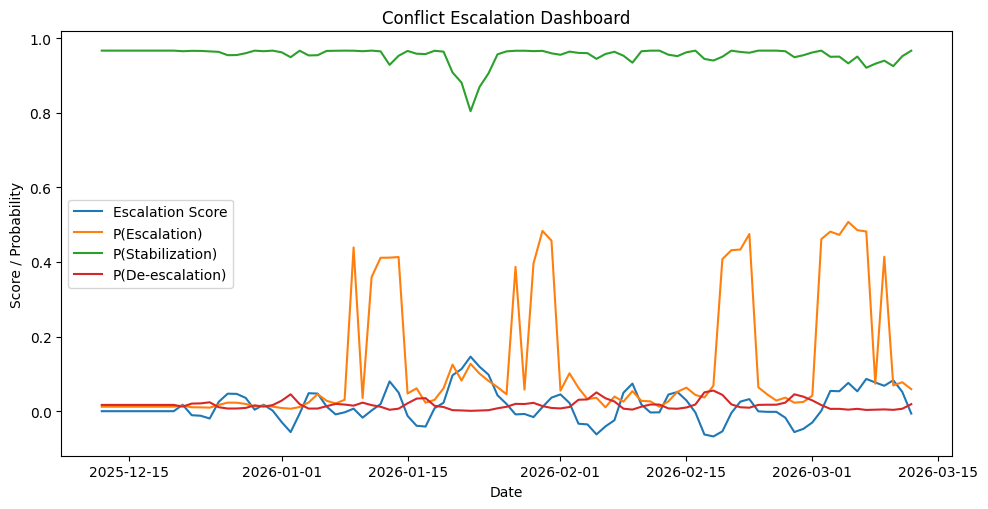

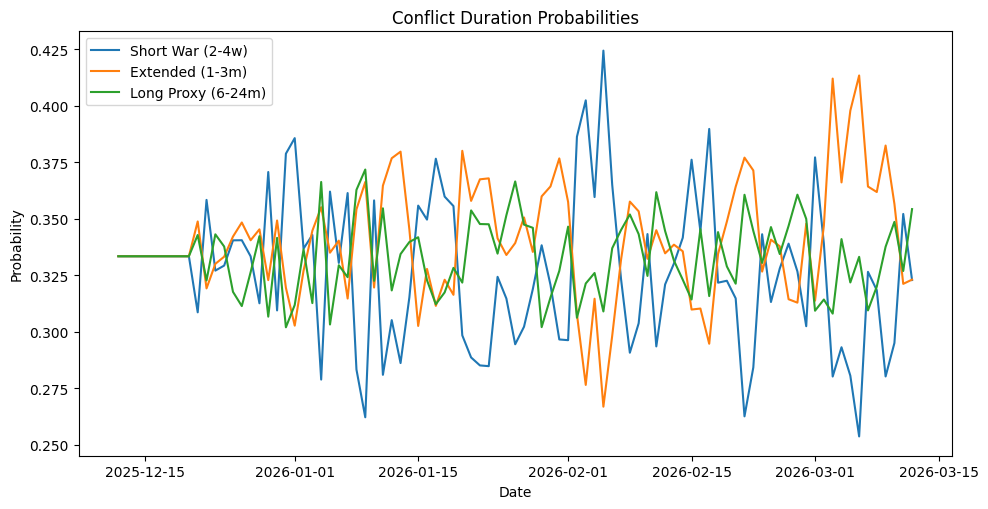

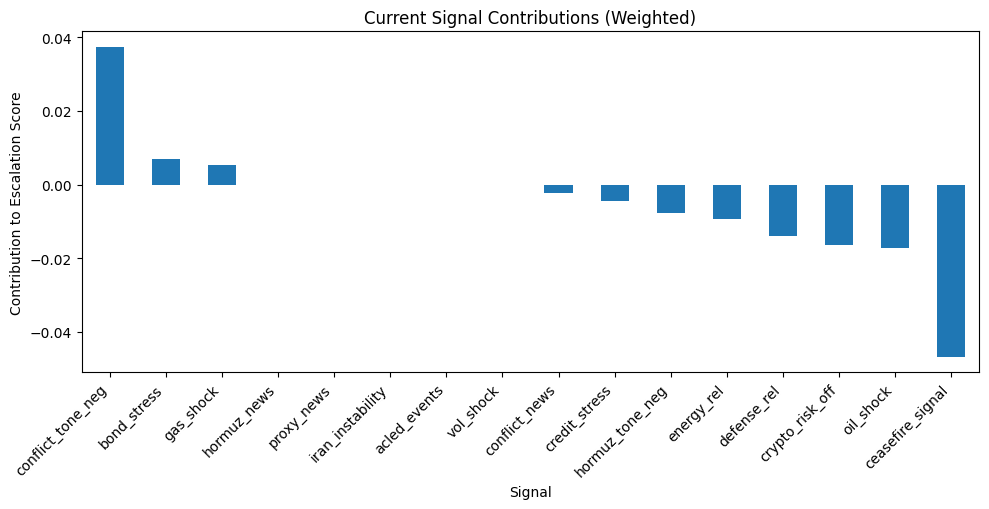

Saved: conflict_escalation_dashboard_output.csv, conflict_dashboard_latest.csv


In [8]:

# SECTION 8 — Charts and CSV exports

# ── Backtest validation chart ────────────────────────────────────────────
# Full-history market-signal escalation score vs verified OSINT operation dates.
# This is the primary validation artifact: shows whether the model elevated
# during TP1 (Apr 2024), TP2 (Oct 2024), and TP4 (Feb-Mar 2026).

# Operation colour map
_OP_COLORS = {"tp1": "#CC4400", "tp2": "#E07B00", "tp3": "#8B0000", "tp4": "#163A5F"}
_OP_LABELS = {"tp1": "TP1 Apr-2024", "tp2": "TP2 Oct-2024",
              "tp3": "TP3", "tp4": "TP4 Feb-2026"}

if not signal_ext.empty and "escalation_score" in signal_ext.columns:
    fig_bt = go.Figure()
    fig_bt.add_trace(go.Scatter(
        x=signal_ext.index, y=signal_ext["escalation_score"],
        mode="lines", name="Escalation Score (market signals)",
        line=dict(color="#4F8BBF", width=1.8)
    ))
    fig_bt.add_hline(y=0, line_dash="dot", line_color="#999999")

    if not ground_truth.empty:
        op_days = ground_truth[ground_truth["is_operation_day"] == 1].copy()
        # Align to trading days
        op_days = op_days[op_days.index.isin(signal_ext.index)]
        seen_ops = set()
        for dt, row in op_days.iterrows():
            op = row["operation_name"]
            color = _OP_COLORS.get(op, "#888888")
            label = _OP_LABELS.get(op, op)
            x_str = str(dt.date())
            fig_bt.add_shape(
                type="line", x0=x_str, x1=x_str, y0=0, y1=1, yref="paper",
                line=dict(width=1, dash="dash", color=color)
            )
            if op not in seen_ops:
                fig_bt.add_annotation(
                    x=x_str, y=1.01, yref="paper", text=label,
                    showarrow=False, textangle=-60,
                    font=dict(size=8, color=color), xanchor="left"
                )
            seen_ops.add(op)

    fig_bt.update_layout(
        title="Backtest Validation: Market Escalation Score vs OSINT Operation Events",
        xaxis_title="Date",
        yaxis_title="Escalation Score",
        height=500, template="plotly_white"
    )
    fig_bt.show()
else:
    print("Backtest chart: extended signal not available.")

# Static PNG for PDF
plt.figure(figsize=(11, 4.5))
if not signal_ext.empty and "escalation_score" in signal_ext.columns:
    plt.plot(signal_ext.index, signal_ext["escalation_score"],
             color="#4F8BBF", linewidth=1.5, label="Escalation Score")
    plt.axhline(0, color="#999999", linestyle=":", linewidth=0.8)
    if not ground_truth.empty:
        op_days = ground_truth[ground_truth["is_operation_day"] == 1]
        op_days = op_days[op_days.index.isin(signal_ext.index)]
        seen_ops_static = set()
        for dt, row in op_days.iterrows():
            op = row["operation_name"]
            color = _OP_COLORS.get(op, "#888888")
            label = _OP_LABELS.get(op, op)
            plt.axvline(dt, color=color, linestyle="--", linewidth=1.0,
                        label=(label if op not in seen_ops_static else "_nolegend_"))
            seen_ops_static.add(op)
    plt.legend(fontsize=8)
else:
    plt.text(0.5, 0.5, "Extended signal unavailable",
             ha="center", va="center", transform=plt.gca().transAxes)
plt.title("Backtest Validation: Market Escalation Score vs OSINT Operations")
plt.xlabel("Date"); plt.ylabel("Escalation Score")
plt.tight_layout()
plt.savefig(OUTPUT_IMG_BACKTEST, dpi=220, bbox_inches="tight")
plt.show()
plt.close()

# Validation metrics table
_val_rows = [
    ["Metric", "Value", "Note"],
    ["Market ROC-AUC", auc_str,
     "Market signals vs OSINT events (in-sample). >0.65 meaningful."],
    ["ICEI 90% CI", ci_str,
     "Bootstrap resampled from last 30 trading days."],
    ["Weight opt. target", "OSINT ground truth" if not ground_truth.empty else "market heuristic",
     "LogReg signal weights fitted against OSINT operation days."],
    ["Operation days in history",
     str(int(ground_truth["is_operation_day"].sum())) if not ground_truth.empty else "N/A",
     "Used for signal weight optimisation (LogReg)."],
    ["Regime thresholds (fixed)",
     "score>0.25=Escalation | 0.10-0.25=Elevated Risk | <-0.10=De-escalation",
     "Score-primary fixed thresholds; no ML calibration"],
    ["Walk-forward AUC (out-of-sample)",
     wf_result.get("wf_auc_str", "n/a"),
     "Rolling 1-month test windows, no in-sample fitting. >0.60 meaningful."],
]
print("\n=== VALIDATION METRICS ===")
for r in _val_rows[1:]:
    print(f"  {r[0]:<35} {r[1]:<20} {r[2]}")


# ── Escalation Index history chart ──────────────────────────────────────
if len(idx_hist) >= 2:
    fig_idx = go.Figure()
    fig_idx.add_trace(go.Scatter(
        x=idx_hist["run_timestamp"],
        y=idx_hist["escalation_index"],
        mode="lines+markers",
        name="ICEI",
        line=dict(color="#163A5F", width=2.5),
        marker=dict(size=7)
    ))
    fig_idx.add_hline(y=50, line_dash="dot", line_color="#999999",
                      annotation_text="Neutral (50)", annotation_position="right")
    fig_idx.add_hline(y=70, line_dash="dash", line_color="#CC4400",
                      annotation_text="Elevated (70)", annotation_position="right")
    fig_idx.update_layout(
        title="Iran Conflict Escalation Index (ICEI) — Run History",
        xaxis_title="Run Timestamp",
        yaxis_title="Index (0–100)",
        yaxis=dict(range=[0, 100]),
        height=480,
        template="plotly_white"
    )
    fig_idx.show()
else:
    print("ICEI history chart: need ≥2 runs to plot trend (current run saved to history).")

# Component breakdown bar chart (current run)
component_labels = [
    f"OSINT/Events\n({BASE_WEIGHTS['osint']}%)",
    f"Neg. Sentiment\n({BASE_WEIGHTS['sentiment']}%)",
    f"Market/Active\n({BASE_WEIGHTS['market']}%)",
]
component_values = [c_osint, c_sentiment, c_market]
component_colors = [
    "#163A5F" if v >= 70 else "#4F8BBF" if v >= 50 else "#A8C8E8"
    for v in component_values
]

fig_comp_icei = go.Figure(go.Bar(
    x=component_labels,
    y=component_values,
    marker_color=component_colors,
    text=[f"{v:.1f}" if v > 0 else "N/A" for v in component_values],
    textposition="outside"
))
fig_comp_icei.add_hline(y=50, line_dash="dot", line_color="#999999",
                        annotation_text="Neutral (50)")
fig_comp_icei.add_hline(y=70, line_dash="dash", line_color="#CC4400",
                        annotation_text="Elevated (70)")
fig_comp_icei.update_layout(
    title=f"ICEI Component Scores — {str(latest_idx.date())}  |  Composite: {escalation_index:.1f}",
    yaxis=dict(range=[0, 110], title="Score (0–100)"),
    xaxis_title="Component",
    template="plotly_white",
    height=420
)
fig_comp_icei.show()

# Save static ICEI chart for PDF
plt.figure(figsize=(10, 4))
if len(idx_hist) >= 2:
    plt.plot(idx_hist["run_timestamp"], idx_hist["escalation_index"],
             marker="o", linewidth=2, color="#163A5F", label="ICEI")
    plt.axhline(50, color="#999999", linestyle=":", label="Neutral (50)")
    plt.axhline(70, color="#CC4400", linestyle="--", label="Elevated (70)")
    plt.ylim(0, 100)
    plt.xticks(rotation=30, ha="right", fontsize=8)
    plt.legend()
else:
    plt.text(0.5, 0.5, f"ICEI: {escalation_index:.1f}\n(run history starts here)",
             ha="center", va="center", fontsize=14, transform=plt.gca().transAxes)
    plt.ylim(0, 100)
plt.title("Iran Conflict Escalation Index (ICEI)")
plt.xlabel("Run Timestamp")
plt.ylabel("Index (0–100)")
plt.tight_layout()
plt.savefig(OUTPUT_IMG_INDEX, dpi=220, bbox_inches="tight")
plt.show()
plt.close()

# Interactive charts
fig_esc = go.Figure()
fig_esc.add_trace(go.Scatter(x=signal.index, y=signal["escalation_score"], mode='lines', name='Escalation Score'))
fig_esc.add_trace(go.Scatter(x=signal.index, y=signal["p_escalation"], mode='lines', name='P(Escalation)'))
fig_esc.add_trace(go.Scatter(x=signal.index, y=signal["p_stabilization"], mode='lines', name='P(Stabilization)'))
fig_esc.add_trace(go.Scatter(x=signal.index, y=signal["p_deescalation"], mode='lines', name='P(De-escalation)'))
fig_esc.update_layout(title='Conflict Escalation Dashboard', xaxis_title='Date', yaxis_title='Score / Probability', height=600, template='plotly_white')
fig_esc.show()

fig_dur = go.Figure()
fig_dur.add_trace(go.Scatter(x=duration.index, y=duration["p_short_war_2_4w"], mode='lines', name='Short War (2-4w)'))
fig_dur.add_trace(go.Scatter(x=duration.index, y=duration["p_extended_1_3m"], mode='lines', name='Extended (1-3m)'))
fig_dur.add_trace(go.Scatter(x=duration.index, y=duration["p_long_proxy_6_24m"], mode='lines', name='Long Proxy (6m+)'))
fig_dur.update_layout(title='Conflict Duration Probabilities', xaxis_title='Date', yaxis_title='Probability', height=600, template='plotly_white')
fig_dur.show()

plot_contrib = active_contrib.copy()
fig_contrib = go.Figure(go.Bar(x=plot_contrib.index, y=plot_contrib.values))
fig_contrib.update_layout(
    title='Current Signal Contributions (Weighted, Active Only)',
    xaxis_title='Signal',
    yaxis_title='Contribution to Escalation Score',
    template='plotly_white'
)
fig_contrib.show()

print("Signals contributing ~0 or unavailable in this run:")
print(", ".join(zero_or_unavailable_signals))

# Static images for PDF (matplotlib avoids kaleido dependency issues)
plt.figure(figsize=(10, 5.2))
plt.plot(signal.index, signal["escalation_score"], label='Escalation Score')
plt.plot(signal.index, signal["p_escalation"], label='P(Escalation)')
plt.plot(signal.index, signal["p_stabilization"], label='P(Stabilization)')
plt.plot(signal.index, signal["p_deescalation"], label='P(De-escalation)')
plt.title('Conflict Escalation Dashboard')
plt.xlabel('Date')
plt.ylabel('Score / Probability')
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_IMG_ESC, dpi=220, bbox_inches='tight')
plt.show()
plt.close()

plt.figure(figsize=(10, 5.2))
plt.plot(duration.index, duration["p_short_war_2_4w"], label='Short War (2-4w)')
plt.plot(duration.index, duration["p_extended_1_3m"], label='Extended (1-3m)')
plt.plot(duration.index, duration["p_long_proxy_6_24m"], label='Long Proxy (6m+)')
plt.title('Conflict Duration Probabilities')
plt.xlabel('Date')
plt.ylabel('Probability')
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_IMG_DUR, dpi=220, bbox_inches='tight')
plt.show()
plt.close()

plt.figure(figsize=(10, 5.2))
plot_contrib.plot(kind='bar')
plt.title('Current Signal Contributions (Weighted, Active Only)')
plt.xlabel('Signal')
plt.ylabel('Contribution to Escalation Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(OUTPUT_IMG_CONTRIB, dpi=220, bbox_inches='tight')
plt.show()
plt.close()

out_df = ind.merge(signal, left_index=True, right_index=True).merge(duration, left_index=True, right_index=True)
out_df.to_csv(OUTPUT_CSV_FULL)
dashboard.to_csv(OUTPUT_CSV_LATEST)
availability_df.to_csv(OUTPUT_DIR + "data_availability_summary.csv")

# ── P4: OSINT lead/lag chart ─────────────────────────────────────────────────
if lead_lag_result is not None:
    lags = lead_lag_result["lag_days"]
    corrs = lead_lag_result["correlations"]
    peak_lag = lead_lag_result["peak_lag"]
    peak_corr = lead_lag_result["peak_corr"]

    fig_ll = go.Figure()
    fig_ll.add_trace(go.Bar(
        x=lags, y=corrs,
        marker_color=["#CC4400" if l == peak_lag else "#4F8BBF" for l in lags],
    ))
    fig_ll.add_vline(x=0, line_dash="dot", line_color="#999999")
    fig_ll.update_layout(
        title=(f"OSINT Lead/Lag: Peak at lag={peak_lag}d (r={peak_corr:.3f}) — "
               + ("OSINT leads market ✓" if peak_lag > 0 else
                  "Market leads OSINT" if peak_lag < 0 else "Coincident")),
        xaxis_title="Lag (days, positive = OSINT leads market)",
        yaxis_title="Pearson r", height=400, template="plotly_white"
    )
    fig_ll.show()

    plt.figure(figsize=(8, 3.5))
    plt.bar(lags, corrs, color=["#CC4400" if l == peak_lag else "#4F8BBF" for l in lags])
    plt.axvline(0, color="#999999", linestyle=":", linewidth=0.8)
    plt.xlabel("Lag (days) — positive = OSINT leads market")
    plt.ylabel("Pearson r")
    plt.title(f"OSINT Lead/Lag  |  Peak lag={peak_lag}d  r={peak_corr:.3f}")
    plt.tight_layout()
    plt.savefig(OUTPUT_IMG_LEADLAG, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"Lead/lag chart → {OUTPUT_IMG_LEADLAG}")
else:
    print("Lead/lag: insufficient data.")

# ── P2: Confirming signal display ────────────────────────────────────────────
print("\n=== MARKET CORROBORATION LAYER (confirming — not used in regime trigger) ===")
if confirming_signals:
    conf_df = pd.DataFrame.from_dict(confirming_signals, orient="index",
                                     columns=["Value [-1,+1]"])
    conf_df["Interpretation"] = conf_df["Value [-1,+1]"].apply(
        lambda v: "Corroborating escalation" if v > 0.2 else
                  "Corroborating de-escalation" if v < -0.2 else "Neutral"
    )
    display(conf_df)
    if confirming_score_latest is not None:
        direction = ("corroborating escalation" if confirming_score_latest > 0.1 else
                     "corroborating de-escalation" if confirming_score_latest < -0.1 else "neutral")
        print(f"Composite confirming score: {confirming_score_latest:+.3f} ({direction})")


## Section 9 — Generate PDF

In [9]:

# SECTION 9 — Generate PDF
from reportlab.lib.pagesizes import letter
from reportlab.lib import colors
from reportlab.lib.units import inch
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.enums import TA_LEFT, TA_CENTER
from reportlab.platypus import (
    SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle,
    Image, PageBreak
)

def wrapped_cell(text, style):
    safe = str(text).replace("&", "&amp;").replace("<", "&lt;").replace(">", "&gt;")
    return Paragraph(safe, style)

doc = SimpleDocTemplate(
    OUTPUT_PDF,
    pagesize=letter,
    rightMargin=0.6 * inch,
    leftMargin=0.6 * inch,
    topMargin=0.65 * inch,
    bottomMargin=0.65 * inch,
)
styles = getSampleStyleSheet()

title_style = ParagraphStyle(
    'TitleStyle', parent=styles['Title'], fontName='Helvetica-Bold',
    fontSize=20, leading=24, textColor=colors.HexColor('#163A5F'),
    alignment=TA_CENTER, spaceAfter=10
)
subtitle_style = ParagraphStyle(
    'SubtitleStyle', parent=styles['Normal'], fontName='Helvetica',
    fontSize=10, leading=13, textColor=colors.HexColor('#4F5D75'),
    alignment=TA_CENTER, spaceAfter=18
)
section_style = ParagraphStyle(
    'SectionStyle', parent=styles['Heading2'], fontName='Helvetica-Bold',
    fontSize=12, leading=15, textColor=colors.HexColor('#163A5F'),
    spaceBefore=10, spaceAfter=8
)
body_style = ParagraphStyle(
    'BodyStyle', parent=styles['BodyText'], fontName='Helvetica',
    fontSize=9.5, leading=13, textColor=colors.black,
    alignment=TA_LEFT, spaceAfter=7
)
small_style = ParagraphStyle(
    'SmallStyle', parent=styles['BodyText'], fontName='Helvetica',
    fontSize=8, leading=11, textColor=colors.HexColor('#555555'),
    alignment=TA_LEFT, spaceAfter=6
)
cell_style = ParagraphStyle(
    'CellStyle', parent=styles['BodyText'], fontName='Helvetica',
    fontSize=8.8, leading=10.5, alignment=TA_LEFT
)

story = []
story.append(Paragraph('Conflict Escalation Dashboard Report', title_style))
story.append(Paragraph(
    f'Automated portfolio risk monitor | Generated {datetime.utcnow().strftime("%Y-%m-%d %H:%M UTC")}',
    subtitle_style
))
story.append(Paragraph(
    # Fix 9: tightened to answer the four page-1 questions; Fix 10: honest framing
    "Structured monitoring and regime-classification framework for Iran-linked conflict escalation "
    "risk. Signal inputs: market-derived indicators, RSS/GDELT news proxies, OSINT-verified events, "
    "and ML-derived escalation probabilities. This is not a conflict forecast — it is a "
    "probabilistic regime-assessment and portfolio-positioning aid.",
    body_style
))
story.append(Spacer(1, 0.12 * inch))

summary_rows = [
    ['Metric', 'Latest'],
    ['Escalation Score', fmt_num(signal.loc[latest_idx, 'escalation_score'])],
    ['Escalation Index (ICEI)', f"{escalation_index:.1f} / 100"],
    ['Δ vs Prev Run', delta_str],
    ['Δ vs 7-Day', delta_7d_str],
    ['ICEI 90% CI', ci_str if 'ci_str' in dir() else 'N/A'],
    ['Market ROC-AUC', auc_str if 'auc_str' in dir() else 'N/A'],
    [f'  • OSINT/Events ({W_OSINT*100:.1f}%)',      f"{c_osint:.1f}" if c_osint is not None else 'N/A'],
    [f'  • Neg. Sentiment ({W_SENTIMENT*100:.1f}%)', f"{c_sentiment:.1f}" if c_sentiment is not None else 'N/A'],
    [f'  • Market/Active ({W_MARKET*100:.1f}%)',     f"{c_market:.1f}" if c_market is not None else 'N/A'],
    ['Regime thresholds (fixed)',
     'score>0.25 Escalation | 0.10-0.25 Elevated Risk | <-0.10 De-escalation'],
    ['Walk-forward AUC (OOS)',
     wf_result.get('wf_auc_str', 'n/a')],
    # Fix 1: renamed from 'Model Confidence' — this is data availability, not forecast certainty
    ['Signal Coverage', f"{fmt_pct(data_completeness)} of signal weight with live data"],
    ['P(De-escalation)', fmt_pct(signal.loc[latest_idx, 'p_deescalation'])],
    ['P(Stabilization)', fmt_pct(signal.loc[latest_idx, 'p_stabilization'])],
    ['P(Escalation)', fmt_pct(signal.loc[latest_idx, 'p_escalation'])],
    ['P(Short War 2-4w)', fmt_pct(duration.loc[latest_idx, 'p_short_war_2_4w'])],
    ['P(Extended 1-3m)', fmt_pct(duration.loc[latest_idx, 'p_extended_1_3m'])],
    ['P(Long Proxy 6m+)', fmt_pct(duration.loc[latest_idx, 'p_long_proxy_6_24m'])],
    ['Portfolio Regime', signal.loc[latest_idx, 'portfolio_regime']],
    ['Recommended Action', signal.loc[latest_idx, 'recommended_actions']],
]
summary_rows = [[wrapped_cell(a, cell_style), wrapped_cell(b, cell_style)] if i > 0 else [a, b] for i, (a, b) in enumerate(summary_rows)]
summary_table = Table(summary_rows, colWidths=[2.15 * inch, 4.85 * inch])
summary_table.setStyle(TableStyle([
    ('BACKGROUND', (0, 0), (-1, 0), colors.HexColor('#163A5F')),
    ('TEXTCOLOR', (0, 0), (-1, 0), colors.white),
    ('FONTNAME', (0, 0), (-1, 0), 'Helvetica-Bold'),
    ('FONTSIZE', (0, 0), (-1, -1), 9),
    ('ROWBACKGROUNDS', (0, 1), (-1, -1), [colors.whitesmoke, colors.HexColor('#EEF3F8')]),
    ('GRID', (0, 0), (-1, -1), 0.4, colors.HexColor('#AAB7C4')),
    ('VALIGN', (0, 0), (-1, -1), 'TOP'),
    ('LEFTPADDING', (0, 0), (-1, -1), 8),
    ('RIGHTPADDING', (0, 0), (-1, -1), 8),
    ('TOPPADDING', (0, 0), (-1, -1), 6),
    ('BOTTOMPADDING', (0, 0), (-1, -1), 6),
]))
story.append(summary_table)
story.append(Spacer(1, 0.18 * inch))

story.append(Paragraph('Interpretation', section_style))
story.append(Paragraph(
    # Fix 1 & 10: removed misleading 'confidence' framing; Fix 9: answers 'what is regime / what changed'
    f"Current regime: <b>{signal.loc[latest_idx, 'portfolio_regime']}</b>. "
    f"Signal coverage: <b>{fmt_pct(data_completeness)}</b> of core signal families active "
    f"(this reflects data availability, not statistical certainty of the regime assessment). "
    f"Run-over-run delta: <b>{delta_str}</b>. "
    f"Near-term duration probabilities are tilted toward extended conflict "
    f"(<b>{fmt_pct(duration.loc[latest_idx, 'p_extended_1_3m'])}</b> for 1–3 months).",
    body_style
))

# Fix 3: Regime Change Triggers — what would cause a reassessment
story.append(Paragraph('Regime Change Triggers', section_style))
story.append(Paragraph(
    "The following conditions, if sustained, would argue for a regime reassessment:",
    body_style
))
_trigger_rows = [
    ['Trigger', 'Direction'],
    ['Sustained ICEI move above 70 with confirmation from OSINT/events and market-active layers',
     'Toward Escalation'],
    ['P(Escalation) rising above P(Stabilization) for two or more consecutive runs',
     'Toward Escalation'],
    ['Repeated worsening in run-over-run delta (ICEI) without reversal',
     'Toward Escalation'],
    ['Sustained ICEI decline below 40 with de-escalation signals from sentiment and OSINT layers',
     'Toward De-escalation'],
    ['P(De-escalation) rising above 50% with corroborating market signal convergence',
     'Toward De-escalation'],
]
_trigger_rows = [[wrapped_cell(a, cell_style), wrapped_cell(b, cell_style)]
                 if i > 0 else [a, b] for i, (a, b) in enumerate(_trigger_rows)]
trigger_tbl = Table(_trigger_rows, colWidths=[5.5 * inch, 1.7 * inch])
trigger_tbl.setStyle(TableStyle([
    ('BACKGROUND', (0, 0), (-1, 0), colors.HexColor('#4F5D75')),
    ('TEXTCOLOR', (0, 0), (-1, 0), colors.white),
    ('FONTNAME', (0, 0), (-1, 0), 'Helvetica-Bold'),
    ('FONTSIZE', (0, 0), (-1, -1), 8.5),
    ('ROWBACKGROUNDS', (0, 1), (-1, -1), [colors.whitesmoke, colors.HexColor('#EEF3F8')]),
    ('GRID', (0, 0), (-1, -1), 0.4, colors.HexColor('#AAB7C4')),
    ('VALIGN', (0, 0), (-1, -1), 'TOP'),
    ('LEFTPADDING', (0, 0), (-1, -1), 7),
    ('RIGHTPADDING', (0, 0), (-1, -1), 7),
    ('TOPPADDING', (0, 0), (-1, -1), 5),
    ('BOTTOMPADDING', (0, 0), (-1, -1), 5),
]))
story.append(trigger_tbl)
story.append(Paragraph(
    "Note: thresholds above are directional guides derived from the current ICEI scale and "
    "probability framework, not statistically calibrated confidence bounds.",
    small_style
))
story.append(Spacer(1, 0.1 * inch))

story.append(Paragraph('Data availability', section_style))
avail_rows = [['Layer', 'Status']] + [[k, v] for k, v in availability_summary.items()]
avail_rows = [[wrapped_cell(a, cell_style), wrapped_cell(b, cell_style)] if i > 0 else [a, b] for i, (a, b) in enumerate(avail_rows)]
avail_table = Table(avail_rows, colWidths=[2.6 * inch, 1.4 * inch])
avail_table.setStyle(TableStyle([
    ('BACKGROUND', (0, 0), (-1, 0), colors.HexColor('#163A5F')),
    ('TEXTCOLOR', (0, 0), (-1, 0), colors.white),
    ('FONTNAME', (0, 0), (-1, 0), 'Helvetica-Bold'),
    ('ROWBACKGROUNDS', (0, 1), (-1, -1), [colors.whitesmoke, colors.HexColor('#EEF3F8')]),
    ('GRID', (0, 0), (-1, -1), 0.4, colors.HexColor('#AAB7C4')),
    ('VALIGN', (0, 0), (-1, -1), 'TOP'),
]))
story.append(avail_table)
story.append(Paragraph(
    # Fix 1: clarify what 'Signal Coverage' means so no reader conflates it with forecast certainty
    "Signal Coverage (shown in the summary table) reflects the fraction of core signal families "
    "currently returning live data. It is not a measure of statistical confidence or forecast accuracy.",
    small_style
))
story.append(Spacer(1, 0.12 * inch))

story.append(Paragraph('Method / caveat notes', section_style))
story.append(Paragraph(
    "Missing signals no longer dilute the model. The escalation score is availability-adjusted so only live signal families contribute to the normalized score. "
    "If GDELT is rate-limited, the notebook attempts to backfill with RSS-derived keyword signals; if ACLED is unavailable, the event layer remains neutral. "
    "The ICEI uses a 3-component structure aligned with the conflictly.app GTI methodology: "
    "OSINT/Events (47.1%), Negative Sentiment (23.5%), Market/Active Conflict (29.4%). "
    "RF signal anomalies (conflictly base: 15%) are held as a planned gap. "
    "Market signal weights are empirically derived via logistic regression on OSINT-verified operation days "
    "(non-circular ground truth). The Random Forest classifier uses the same OSINT ground truth as its training "
    "target, replacing the previous circular market-threshold heuristic. "
    "ICEI confidence interval is bootstrapped from the last 30 trading days of each signal.",
    small_style
))
story.append(PageBreak())

# ── P1: Sub-sector positioning table ──────────────────────────────────────────
story.append(Paragraph('Sub-Sector Positioning Guidance', section_style))
story.append(Paragraph(
    'Sub-sector breakdown for the current portfolio regime. '
    'Note: defense primes carry a 6-18 month procurement lag; '
    'refining margins compress when crude spikes without demand recovery.',
    small_style
))
_current_regime_pdf = signal.loc[latest_idx, 'portfolio_regime'] if 'portfolio_regime' in signal.columns else 'Stabilization'
_ss_map_pdf = {
    "Escalation": [
        ("Upstream E&P (XOP)", "Overweight — direct spot crude leverage"),
        ("Midstream (AM / AMLP)", "Neutral — infrastructure insulated"),
        ("Refining (VLO, PSX)", "Underweight — margin squeeze risk"),
        ("Defense primes (LMT, RTX, NOC)", "Overweight — contract backlog benefits"),
        ("Defense services (CACI, SAIC)", "Neutral — 6-18m procurement lag"),
        ("Broad energy (XLE)", "Overweight — prefer XOP for purer exposure"),
    ],
    "De-escalation": [
        ("Upstream E&P (XOP)", "Reduce tactically — risk premium deflates"),
        ("Midstream (AM / AMLP)", "Add on weakness — yield attractive"),
        ("Refining (VLO, PSX)", "Overweight — crack spreads normalise"),
        ("Defense primes (LMT, RTX, NOC)", "Neutral — procurement unaffected"),
        ("Defense services (CACI, SAIC)", "Neutral"),
        ("Broad energy (XLE)", "Reduce tactical overweight; rotate to cyclicals"),
    ],
    "Stabilization": [
        ("Upstream E&P (XOP)", "Neutral"),
        ("Midstream (AM / AMLP)", "Neutral — hold for income"),
        ("Refining (VLO, PSX)", "Neutral"),
        ("Defense primes (LMT, RTX, NOC)", "Neutral — maintain existing position"),
        ("Defense services (CACI, SAIC)", "Neutral"),
        ("Broad energy (XLE)", "Neutral"),
    ],
}
ss_rows = [["Sub-sector", f"Guidance ({_current_regime_pdf} regime)"]]
for sub, guidance in _ss_map_pdf.get(_current_regime_pdf, _ss_map_pdf["Stabilization"]):
    ss_rows.append([wrapped_cell(sub, cell_style), wrapped_cell(guidance, cell_style)])
ss_tbl = Table(ss_rows, colWidths=[2.8 * inch, 4.4 * inch])
ss_tbl.setStyle(TableStyle([
    ('BACKGROUND', (0, 0), (-1, 0), colors.HexColor('#163A5F')),
    ('TEXTCOLOR', (0, 0), (-1, 0), colors.white),
    ('FONTNAME', (0, 0), (-1, 0), 'Helvetica-Bold'),
    ('ROWBACKGROUNDS', (0, 1), (-1, -1), [colors.whitesmoke, colors.HexColor('#EEF3F8')]),
    ('GRID', (0, 0), (-1, -1), 0.4, colors.HexColor('#AAB7C4')),
    ('VALIGN', (0, 0), (-1, -1), 'TOP'),
]))
story.append(ss_tbl)
story.append(Spacer(1, 0.15 * inch))

# ── P2: Market corroboration layer ────────────────────────────────────────────
story.append(Paragraph('Market Corroboration Layer', section_style))
story.append(Paragraph(
    # Fix 7: sharper explanation of purpose and divergence handling
    "These market-return signals (XLE/SPY, ITA/SPY, TLT, HYG, BTC) are structurally lagging "
    "and confirming — they do NOT drive regime classification. They exist to validate whether "
    "market prices have already moved in the direction implied by the causal signal layer. "
    "Alignment between the corroboration layer and causal layer increases regime confidence. "
    "Divergence — where market prices have not confirmed the causal read — should be treated "
    "as a flag for caution rather than a reason to dismiss the causal signal.",
    small_style
))
_conf_names = {"energy_rel": "XLE vs SPY (5d)", "defense_rel": "ITA vs SPY (5d)",
               "bond_stress": "TLT (inverted)", "credit_stress": "HYG (inverted)",
               "crypto_risk_off": "BTC (inverted)"}
_conf_rows = [["Signal", "Value", "Interpretation"]]
for k, label in _conf_names.items():
    v = float(signal.loc[latest_idx, k]) if k in signal.columns else float('nan')
    interp = ("Corroborating escalation" if v > 0.2 else
              "Corroborating de-escalation" if v < -0.2 else "Neutral / inconclusive")
    _conf_rows.append([wrapped_cell(label, cell_style),
                       wrapped_cell(f"{v:+.3f}", cell_style),
                       wrapped_cell(interp, cell_style)])
conf_tbl = Table(_conf_rows, colWidths=[2.2 * inch, 1.1 * inch, 3.9 * inch])
conf_tbl.setStyle(TableStyle([
    ('BACKGROUND', (0, 0), (-1, 0), colors.HexColor('#4F5D75')),
    ('TEXTCOLOR', (0, 0), (-1, 0), colors.white),
    ('FONTNAME', (0, 0), (-1, 0), 'Helvetica-Bold'),
    ('ROWBACKGROUNDS', (0, 1), (-1, -1), [colors.whitesmoke, colors.HexColor('#EEF3F8')]),
    ('GRID', (0, 0), (-1, -1), 0.4, colors.HexColor('#AAB7C4')),
    ('VALIGN', (0, 0), (-1, -1), 'TOP'),
]))
story.append(conf_tbl)
story.append(Spacer(1, 0.1 * inch))

story.append(PageBreak())

story.append(Paragraph('Conflict Escalation Trend', section_style))
story.append(Image(OUTPUT_IMG_ESC, width=7.1 * inch, height=4.0 * inch))
story.append(Spacer(1, 0.18 * inch))
story.append(Paragraph('Conflict Duration Probabilities', section_style))
story.append(Image(OUTPUT_IMG_DUR, width=7.1 * inch, height=4.0 * inch))
story.append(PageBreak())

story.append(Paragraph('Backtest Validation', section_style))
if os.path.exists(OUTPUT_IMG_BACKTEST):
    story.append(Image(OUTPUT_IMG_BACKTEST, width=7.1 * inch, height=3.8 * inch))
story.append(Paragraph(
    f'Full-history market escalation score vs OSINT-verified operation events '
    f'(dashed vertical lines). Market ROC-AUC: {auc_str}. '
    # Fix 10: soften 'validates' — consistent with, not proof of, causal capture
    'A score elevated during operation windows and near 0 in calm periods is '  
    'consistent with the market signal layer tracking conflict-related price dynamics. '  
    'This supports the framework as a monitoring tool; it does not establish '  
    'predictive accuracy or causal attribution.',
    small_style
))
story.append(PageBreak())

# ── P4: OSINT lead/lag chart ──────────────────────────────────────────────────
if os.path.exists(OUTPUT_IMG_LEADLAG):
    story.append(Paragraph('OSINT Lead/Lag Validation', section_style))
    _ll = lead_lag_result or {}
    _ll_desc = (
        f"Peak correlation at lag={_ll.get('peak_lag','n/a')} days "
        f"(r={_ll.get('peak_corr', float('nan')):.3f}). "
        # Fix 5: honest framing — coincident result described as monitoring signal, not predictor
        + ("OSINT leads the market signal at this lag — consistent with the event layer "
           "providing some forward information. Use as a real-time monitoring input, "
           "not a standalone timing signal."
           if (_ll.get('peak_lag') or 0) > 0 else
           "Market leads OSINT at this lag — prices may be moving before events are "
           "captured in the database. Treat event-based confirming signals with extra caution."
           if (_ll.get('peak_lag') or 0) < 0 else
           "The current result is primarily coincident (lag=0): OSINT operation days and "
           "the market signal are moving together rather than one clearly leading the other. "
           "This supports use as a real-time monitoring framework rather than a standalone "
           "predictive timing signal. ")
        + "Positive lag = OSINT preceded the market escalation signal by that many trading days. "
        "Bars are Pearson r at each offset. Treat all lead/lag results as indicative given "
        "limited operation-day sample size."
    )
    story.append(Image(OUTPUT_IMG_LEADLAG, width=7.1 * inch, height=3.2 * inch))
    story.append(Paragraph(_ll_desc, small_style))
    story.append(Spacer(1, 0.15 * inch))

# Fix 4: ICEI interpretive range guide
story.append(Paragraph('Escalation Index (ICEI) History', section_style))
_icei_guide = [
    ['ICEI Range', 'Interpretation'],
    ['0 – 30',  'Low conflict pressure — minimal signal activation across components'],
    ['30 – 50', 'Below-neutral — some signal activation but below historical midpoint'],
    ['50 – 70', 'Stabilization / mixed — elevated but not dominant escalation read'],
    ['70 – 100', 'Elevated escalation pressure — broad signal activation; treat as actionable'],
]
_icei_guide = [[wrapped_cell(a, cell_style), wrapped_cell(b, cell_style)]
               if i > 0 else [a, b] for i, (a, b) in enumerate(_icei_guide)]
icei_guide_tbl = Table(_icei_guide, colWidths=[1.3 * inch, 5.9 * inch])
icei_guide_tbl.setStyle(TableStyle([
    ('BACKGROUND', (0, 0), (-1, 0), colors.HexColor('#4F5D75')),
    ('TEXTCOLOR', (0, 0), (-1, 0), colors.white),
    ('FONTNAME', (0, 0), (-1, 0), 'Helvetica-Bold'),
    ('FONTSIZE', (0, 0), (-1, -1), 8.5),
    ('ROWBACKGROUNDS', (0, 1), (-1, -1), [colors.whitesmoke, colors.HexColor('#EEF3F8')]),
    ('GRID', (0, 0), (-1, -1), 0.4, colors.HexColor('#AAB7C4')),
    ('VALIGN', (0, 0), (-1, -1), 'TOP'),
    ('LEFTPADDING', (0, 0), (-1, -1), 7),
    ('TOPPADDING', (0, 0), (-1, -1), 4),
    ('BOTTOMPADDING', (0, 0), (-1, -1), 4),
]))
story.append(icei_guide_tbl)
story.append(Paragraph(
    "ICEI ranges are derived from the 0–100 scaling of the composite escalation score "
    "(50 = neutral baseline). Ranges are descriptive guides, not calibrated probability thresholds.",
    small_style
))
story.append(Spacer(1, 0.08 * inch))
story.append(Image(OUTPUT_IMG_INDEX, width=7.1 * inch, height=3.4 * inch))
story.append(Paragraph(
    'The Iran Conflict Escalation Index (ICEI) maps the model\'s escalation score to a 0–100 scale '
    '(50 = neutral baseline, 70+ = elevated, 100 = maximum). '
    'Each data point represents one notebook run. Use the run-over-run delta to detect directional shifts.',
    small_style
))
story.append(PageBreak())

story.append(Paragraph('Signal Contributions', section_style))
story.append(Image(OUTPUT_IMG_CONTRIB, width=6.9 * inch, height=4.3 * inch))
story.append(Spacer(1, 0.12 * inch))
story.append(Paragraph('Inactive / unavailable signals', section_style))
story.append(Paragraph(", ".join(zero_or_unavailable_signals) if zero_or_unavailable_signals else "None", small_style))
# Fix 6: surface missing signals as an explicit model limitation
if zero_or_unavailable_signals:
    story.append(Paragraph(
        "Warning: one or more signal components are currently inactive or returning neutral values. "
        "While the model adjusts for availability, missing components reduce coverage breadth and "
        "may reduce sensitivity to fast-moving escalation dynamics. Treat the current regime "
        "classification with additional caution where key event-driven signals are absent.",
        small_style
    ))

# Fix 8: removed duplicate summary metrics table; retain only delta / probability
# supplement rows not already shown on page 1
story.append(Paragraph('Probability Detail (current run)', section_style))
story.append(Paragraph(
    'Full probability breakdown for reference. Core metrics are summarised on page 1.',
    small_style
))
detail_rows = [
    ['Metric', 'Value'],
    ['Escalation Probability',       fmt_pct(signal.loc[latest_idx, 'p_escalation'])],
    ['Stabilization Probability',    fmt_pct(signal.loc[latest_idx, 'p_stabilization'])],
    ['De-escalation Probability',    fmt_pct(signal.loc[latest_idx, 'p_deescalation'])],
    ['Short War (2-4 weeks)',         fmt_pct(duration.loc[latest_idx, 'p_short_war_2_4w'])],
    ['Extended Conflict (1-3 months)', fmt_pct(duration.loc[latest_idx, 'p_extended_1_3m'])],
    ['Long Proxy Conflict (6m+)',     fmt_pct(duration.loc[latest_idx, 'p_long_proxy_6_24m'])],
    ['ICEI Component — OSINT/Events', f"{c_osint:.1f}" if c_osint is not None else 'N/A'],
    ['ICEI Component — Neg. Sentiment', f"{c_sentiment:.1f}" if c_sentiment is not None else 'N/A'],
    ['ICEI Component — Market/Active', f"{c_market:.1f}" if c_market is not None else 'N/A'],
]
detail_rows = [[wrapped_cell(a, cell_style), wrapped_cell(b, cell_style)]
               if i > 0 else [a, b] for i, (a, b) in enumerate(detail_rows)]
detail_table = Table(detail_rows, colWidths=[3.5 * inch, 2.7 * inch])
detail_table.setStyle(TableStyle([
    ('BACKGROUND', (0, 0), (-1, 0), colors.HexColor('#163A5F')),
    ('TEXTCOLOR', (0, 0), (-1, 0), colors.white),
    ('FONTNAME', (0, 0), (-1, 0), 'Helvetica-Bold'),
    ('ROWBACKGROUNDS', (0, 1), (-1, -1), [colors.whitesmoke, colors.HexColor('#EEF3F8')]),
    ('GRID', (0, 0), (-1, -1), 0.4, colors.HexColor('#AAB7C4')),
    ('VALIGN', (0, 0), (-1, -1), 'TOP'),
]))
story.append(detail_table)

doc.build(story)
print(f"Saved PDF report: {OUTPUT_PDF}")


Saved PDF report: conflict_dashboard_report.pdf


## Section 10 — Final output links

In Colab / Jupyter, these paths will be clickable from the file browser after the cells run.

In [10]:

# SECTION 10 — Final output summary

print("Artifacts ready:")
print(f"- Notebook outputs CSV: {OUTPUT_CSV_FULL}")
print(f"- Latest dashboard CSV: {OUTPUT_CSV_LATEST}")
print("- Data availability CSV: data_availability_summary.csv")
print(f"- Escalation index history CSV: {OUTPUT_INDEX_HISTORY}  ({len(idx_hist)} run(s), latest ICEI: {escalation_index:.1f})")
print(f"- Backtest validation chart: {OUTPUT_IMG_BACKTEST}")
print(f"- PDF report: {OUTPUT_PDF}")
if auc_score is not None:
    verdict = "good" if auc_score >= 0.65 else "marginal" if auc_score >= 0.55 else "weak"
    print(f"\nValidation: market ROC-AUC={auc_score:.3f} ({verdict}). "
          f"ICEI 90% CI={ci_str}.")


Artifacts ready:
- Notebook outputs CSV: conflict_escalation_dashboard_output.csv
- Latest dashboard CSV: conflict_dashboard_latest.csv
- PDF report: conflict_dashboard_report.pdf
